# Seismic AI Forecasting — v15 (Publication Ready)

## Changes v14 → v15 (Gap fixes)

| Gap | Fix | Cell |
|-----|-----|------|
| G3 | Permutation significance test — ROC vs null (1000 permutations) | New Cell after bootstrap CI |
| G4 | ETAS-inspired baseline comparison | New Cell after significance test |
| G5 | Limitations section — explicit table for paper | New Cell |

## All v14 features carried forward
- 4 DL models: LSTM, TCN, WaveNet, Transformer (per-zone, stride=1)
- 3 declustered sensitivity experiments
- Isotonic calibration, depth NaN imputation, per-zone importance
- n_pos thresholds, BSS suppression, BSS-preferred exec summary

## Catalog: master_catalog_with_zones_v8.csv (27,745 events, 5 zones)


## 1) Imports and environment

In [4]:
import sys, platform, os, time, json, zipfile, warnings, random
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import shap, sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              brier_score_loss, roc_curve, precision_recall_curve)
from sklearn.inspection import permutation_importance

# Fix C10: guard display() for non-Jupyter contexts
try:
    from IPython.display import display
except ImportError:
    display = print

# Imbalanced-learn — pip install imbalanced-learn
try:
    from imblearn.ensemble import BalancedRandomForestClassifier
    HAVE_IMBLEARN = True
    print('imbalanced-learn: available')
except ImportError:
    HAVE_IMBLEARN = False
    print('imbalanced-learn: NOT found. pip install imbalanced-learn')
    print('  Falling back to class_weight="balanced" RandomForest.')

# XGBoost — pip install xgboost
try:
    from xgboost import XGBClassifier
    HAVE_XGB = True
    print('xgboost: available')
except ImportError:
    HAVE_XGB = False
    print('xgboost: NOT found. pip install xgboost')

import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

warnings.filterwarnings('ignore')
sns.set(style='whitegrid')
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.makedirs('results_figures', exist_ok=True)

# Fix C9: write environment_info.txt (packaging cell references this file)
env = {
    'Python': sys.version.split()[0],
    'Platform': platform.platform(),
    'NumPy': np.__version__,
    'Pandas': pd.__version__,
    'Scikit-Learn': sklearn.__version__,
    'PyTorch': torch.__version__,
    'SHAP': shap.__version__,
}
with open('environment_info.txt', 'w') as f:
    for k, v in env.items():
        f.write(f'{k}: {v}\n')
print(env)


imbalanced-learn: available
xgboost: available
{'Python': '3.12.13', 'Platform': 'Linux-6.6.113+-x86_64-with-glibc2.35', 'NumPy': '2.0.2', 'Pandas': '2.2.2', 'Scikit-Learn': '1.6.1', 'PyTorch': '2.10.0+cu128', 'SHAP': '0.51.0'}


In [5]:
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    COLAB = True
except ImportError:
    COLAB = False
    print('Not in Colab.')


Mounted at /content/drive


## 2) Configuration

In [6]:
# ── Data file ────────────────────────────────────────────────────────────────
DATA_FILE = '/content/drive/MyDrive/Seismic AI/master_catalog_with_zones_v8.csv'

# ── Temporal splits ───────────────────────────────────────────────────────────
TRAIN_START = 1990
TRAIN_END   = 2018
VAL_END     = 2023   # test = 2024–present

# ── Feature computation ───────────────────────────────────────────────────────
# FEATURE_MIN_MAG: above mb→Mw heaping band (4.75–5.25).
FEATURE_MIN_MAG = 5.3
FIXED_DEPTHS    = {10.0, 15.0, 33.0, 35.0}

# ── Targets ───────────────────────────────────────────────────────────────────
DL_TARGET    = 5.5
RF_TARGETS   = [5.5, 6.0, 6.5]
ADD_GLOBAL_M7 = True

# ── Feature windows ───────────────────────────────────────────────────────────
WIN     = [7, 30, 90, 180]
HORIZON = 30

# ── Zone strategy ─────────────────────────────────────────────────────────────
ALL_ZONES = ['Himalaya_HinduKush', 'NE_India', 'Andaman_Nicobar',
             'Makran', 'Peninsular_Shield']
DL_ZONES  = ['Himalaya_HinduKush', 'Andaman_Nicobar']

# ── DL hyperparameters ────────────────────────────────────────────────────────
SEQ_LEN        = 90
EPOCHS         = 80
BATCH          = 32
LR             = 5e-4
PATIENCE       = 12
POS_WEIGHT_CAP = 15.0
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'Train      : {TRAIN_START}–{TRAIN_END}')
print(f'Validation : {TRAIN_END+1}–{VAL_END}')
print(f'Test       : {VAL_END+1}–present')
print(f'FEATURE_MIN_MAG : M≥{FEATURE_MIN_MAG}')
print(f'DL features: count_only (ablation result: best ROC+BSS)')
print(f'DL zones   : {DL_ZONES} (per-zone models)')
print(f'RF targets : {RF_TARGETS}')
print(f'Device     : {DEVICE}')


Train      : 1990–2018
Validation : 2019–2023
Test       : 2024–present
FEATURE_MIN_MAG : M≥5.3
DL features: count_only (ablation result: best ROC+BSS)
DL zones   : ['Himalaya_HinduKush', 'Andaman_Nicobar'] (per-zone models)
RF targets : [5.5, 6.0, 6.5]
Device     : cuda


## 3) Load catalog

In [7]:
df = pd.read_csv(DATA_FILE, parse_dates=['time'])
df['time'] = pd.to_datetime(df['time'], errors='coerce').dt.tz_localize(None)
for c in ['latitude','longitude','depth_km','magnitude']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# Backfill quality flags for catalog compatibility
if 'depth_fixed' not in df.columns:
    df['depth_fixed'] = df['depth_km'].round(1).isin(FIXED_DEPTHS)
if 'in_mb_heaping_band' not in df.columns:
    df['in_mb_heaping_band'] = False
if 'magnitude_heaping' in df.columns and 'in_mb_heaping_band' not in df.columns:
    df['in_mb_heaping_band'] = df['magnitude_heaping']
if 'completeness_era' not in df.columns:
    df['completeness_era'] = 'standard'
if 'is_mainshock' not in df.columns:
    df['is_mainshock'] = True
if 'isc_gap' not in df.columns:
    df['isc_gap'] = False

df = df.dropna(subset=['time','latitude','longitude','depth_km','magnitude','zone'])
# v8 catalog pre-filtered to 3-40N, 60-100E, depth 0-70km — only enforce mag floor
df = df[df.magnitude.between(4.5, 10.0)].copy()
df = df.sort_values('time').reset_index(drop=True)
df['date'] = df['time'].dt.normalize()
df['year'] = df['time'].dt.year

df_model = df[df.year >= TRAIN_START].copy().reset_index(drop=True)
ZONES = [z for z in ALL_ZONES if z in df_model.zone.unique()]

print(f'Full catalog  : {len(df):,} ({df.year.min()}–{df.year.max()})')
print(f'Model dataset : {len(df_model):,} ({TRAIN_START}–{df_model.year.max()})')
print(f'Zones found   : {ZONES}')
print()
print(f'{"Zone":<24} {"n":>6}  {"M≥5.5":>6}  {"M≥6.0":>6}')
for z in ZONES:
    s = df_model[df_model.zone==z]
    print(f'  {z:<22} {len(s):>6}  {(s.magnitude>=5.5).sum():>6}  '
          f'{(s.magnitude>=6.0).sum():>6}')


Full catalog  : 23,695 (1905–2026)
Model dataset : 18,746 (1990–2026)
Zones found   : ['Himalaya_HinduKush', 'NE_India', 'Andaman_Nicobar', 'Makran', 'Peninsular_Shield']

Zone                          n   M≥5.5   M≥6.0
  Himalaya_HinduKush       9371     347      95
  NE_India                 1195      54      20
  Andaman_Nicobar          6762     296      65
  Makran                    568      28       2
  Peninsular_Shield         850      32       7


## 4) Feature engineering (tabular — for LR / BRF / XGB)

### Design decisions
| Feature group | Literature basis | Fix from v6 |
|---|---|---|
| Count at M≥FEATURE_MIN_MAG | Woessner & Wiemer 2005 | Heaping band excluded |
| b-value MLE, mmin=FEATURE_MIN_MAG | Aki 1965; Wiemer & Wyss 2000 | mmin corrected |
| Depth stats — non-fixed depths only | — | Fixed-depth events excluded |
| Seismicity rate ratios | Helmstetter et al. 2003 JGR | Renamed from "ETAS-inspired" |
| CUSUM deviation | Wyss & Habermann 1988 | Baseline = training period only |
| time_since_last_M5/6 | Omori-Utsu (Utsu 1961) | Forward scan O(n) |
| Magnitude gradient | — | Unchanged |

### Performance fixes (C1, C2, C3)
- Dead `past_all` computation removed (C1)
- `rolling_count` uses `pd.Series.rolling().sum()` not Python for loop (C3)
- `days_since` uses O(n) forward scan not O(n×n_events) list comprehension (C2)


In [8]:
# day index shared across all zones
all_days = pd.date_range(df_model.date.min(), df_model.date.max(), freq='D')
train_days_mask = (all_days >= pd.Timestamp(f'{TRAIN_START}-01-01')) & \
                  (all_days <= pd.Timestamp(f'{TRAIN_END}-12-31'))

# Pre-compute Andaman daily counts for cross-zone NE_India feature (E10)
andaman_sub = df_model[
    (df_model.zone == 'Andaman_Nicobar') &
    (df_model.magnitude >= FEATURE_MIN_MAG)
]
andaman_daily = (andaman_sub.groupby('date').size()
                             .reindex(all_days, fill_value=0).astype(float))
andaman_roll30 = andaman_daily.rolling(30, min_periods=0).sum().values


def compute_b_value_mle(magnitudes: np.ndarray,
                         mmin: float = FEATURE_MIN_MAG,
                         dm: float = 0.1) -> float:
    mags = magnitudes[magnitudes >= mmin]
    if len(mags) < 10:
        return 0.0
    denom = mags.mean() - (mmin - dm / 2.0)
    return round(float(np.log10(np.e) / denom), 4) if denom > 0 else 0.0


def build_features_for_zone(sub: pd.DataFrame,
                              zone_name: str = '') -> pd.DataFrame:
    sub_f = sub[sub.magnitude >= FEATURE_MIN_MAG].copy()

    daily_cnt = (sub_f.groupby('date').size()
                      .reindex(all_days, fill_value=0).astype(float))
    roll = {w: daily_cnt.rolling(w, min_periods=0).sum().values for w in WIN}

    baseline_rate = (daily_cnt.values[train_days_mask].sum() /
                     max(train_days_mask.sum(), 1))

    m5_dates = set(sub[sub.magnitude >= 5.0]['date'].values)
    m6_dates = set(sub[sub.magnitude >= 6.0]['date'].values)
    ds_m5 = np.full(len(all_days), 999.0)
    ds_m6 = np.full(len(all_days), 999.0)
    last5 = 999.0; last6 = 999.0
    for i, d in enumerate(all_days):
        d_ts = pd.Timestamp(d)
        if d_ts in m5_dates: last5 = 0.0
        if d_ts in m6_dates: last6 = 0.0
        ds_m5[i] = min(last5, 365.0)
        ds_m6[i] = min(last6, 999.0)
        if last5 < 999.0: last5 += 1
        if last6 < 999.0: last6 += 1

    cusum_arr = np.cumsum(daily_cnt.values - baseline_rate)
    cusum_90  = np.array([
        daily_cnt.values[max(0,i-90):i+1].sum() - (min(i+1,90))*baseline_rate
        for i in range(len(all_days))
    ])

    rows = []
    for i, d in enumerate(all_days):
        f = {'date': d}
        d_ts = pd.Timestamp(d)

        for w in WIN:
            lo = d_ts - pd.Timedelta(days=w)
            p  = sub_f[(sub_f.date > lo) & (sub_f.date <= d_ts)]
            n  = len(p)
            f[f'count_{w}']         = int(roll[w][i])
            f[f'N{w}_Mge5p5']       = int((p.magnitude >= 5.5).sum())
            f[f'N{w}_Mge6p0']       = int((p.magnitude >= 6.0).sum())
            f[f'maxM_{w}']          = float(p.magnitude.max())  if n>0 else 0.0
            f[f'meanM_{w}']         = float(p.magnitude.mean()) if n>0 else 0.0
            p_r = p[~p['depth_fixed']] if 'depth_fixed' in p.columns else p
            nr  = len(p_r)
            f[f'depth_mean_{w}']    = float(p_r.depth_km.mean()) if nr>0 else np.nan
            f[f'depth_std_{w}']     = float(p_r.depth_km.std())  if nr>1 else np.nan
            f[f'pct_fixed_dep_{w}'] = 1.0 - nr / max(n, 1)
            if n > 1:
                iet = p.sort_values('date')['date'].diff().dt.days.dropna()
                f[f'iet_{w}'] = float(iet.mean()) if len(iet)>0 else float(w)
            else:
                f[f'iet_{w}'] = float(w)

        lo90 = d_ts - pd.Timedelta(days=90)
        p90  = sub_f[(sub_f.date > lo90) & (sub_f.date <= d_ts)]
        f['b_est_90'] = compute_b_value_mle(p90.magnitude.values)

        c7   = max(roll[7][i],   1e-3)
        c30  = max(roll[30][i],  1e-3)
        c90  = max(roll[90][i],  1e-3)
        c180 = max(roll[180][i], 1e-3)
        f['rr_7_180']  = round(c7  / c180, 4)
        f['rr_30_180'] = round(c30 / c180, 4)
        f['rr_7_90']   = round(c7  / c90,  4)

        f['cusum_dev'] = round(float(cusum_arr[i]), 4)
        f['cusum_90d'] = round(float(cusum_90[i]),  4)

        f['mgrad_7_30']   = round(f['maxM_7']  - f['maxM_30'],  4)
        f['mgrad_7_90']   = round(f['maxM_7']  - f['maxM_90'],  4)
        f['mgrad_30_180'] = round(f['maxM_30'] - f['maxM_180'], 4)

        f['days_since_M5'] = float(ds_m5[i])
        f['days_since_M6'] = float(ds_m6[i])

        # E10: cross-zone coupling — Andaman 30-day count as NE_India feature
        if zone_name == 'NE_India':
            f['cross_andaman_count_30'] = int(andaman_roll30[i])

        rows.append(f)

    return pd.DataFrame(rows)


print('Building tabular features per zone...')
feat_blocks = []
for z in ZONES:
    t0 = time.time()
    sub = df_model[df_model.zone == z][
        ['date','magnitude','depth_km','depth_fixed']
    ].copy()
    F = build_features_for_zone(sub, zone_name=z)
    F['zone'] = z
    feat_blocks.append(F)
    print(f'  {z}: {len(F)} rows  {time.time()-t0:.1f}s')

features = pd.concat(feat_blocks, ignore_index=True)

feature_cols = [c for c in features.columns if c.startswith((
    'count_','N','maxM_','meanM_','depth_mean_','depth_std_','pct_fixed_dep_',
    'iet_','b_est_','rr_','cusum_','mgrad_','days_since_','cross_'
))]
# F4: Impute NaN depth features with per-zone median
depth_cols = [c for c in features.columns if c.startswith('depth_')]
for col in depth_cols:
    features[col] = features.groupby('zone')[col].transform(
        lambda x: x.fillna(x.median())
    )
    features[col] = features[col].fillna(0.0)

print(f'\n{len(feature_cols)} tabular feature columns')
print(f'Depth NaN imputation applied to {len(depth_cols)} depth columns.')


Building tabular features per zone...
  Himalaya_HinduKush: 13239 rows  91.4s
  NE_India: 13239 rows  65.7s
  Andaman_Nicobar: 13239 rows  82.6s
  Makran: 13239 rows  66.4s
  Peninsular_Shield: 13239 rows  65.1s

48 tabular feature columns
Depth NaN imputation applied to 8 depth columns.


## 5) Label construction (vectorised)

In [9]:
# Fix C4: previous version had a Python for loop over all_days × ZONES.
# Vectorised: for each zone, sort events by date and compute, for every
# calendar day, whether any event at M≥threshold falls within (d, d+HORIZON].
# Implementation: use pd.merge_asof on the sorted event list.

M_TARGETS = RF_TARGETS   # [5.5, 6.0, 6.5]

label_blocks = []
for z in ZONES:
    sub = df_model[df_model.zone == z][['date','magnitude']].copy()
    day_df = pd.DataFrame({'date': all_days})

    for M0 in M_TARGETS:
        # Mark days that have an event at or above M0
        event_days = sub[sub.magnitude >= M0][['date']].copy()
        event_days['_flag'] = True
        event_days = event_days.drop_duplicates('date')

        # For each calendar day d, check if any event exists in (d, d+HORIZON]
        # Efficient: for each event day e, all calendar days in [e-HORIZON, e-1]
        # should receive label=1
        event_dates = np.sort(event_days['date'].values)
        day_dates   = all_days.values

        # Binary-search approach: for each day d find if any event in (d, d+H]
        H = np.timedelta64(HORIZON, 'D')
        # searchsorted finds insertion point; check if event exists in window
        right = np.searchsorted(event_dates, day_dates + H, side='right')
        left  = np.searchsorted(event_dates, day_dates,    side='right')
        labels = (right > left).astype(int)
        day_df[f'label_Mge{M0}'] = labels

    day_df['zone'] = z
    label_blocks.append(day_df)

labels = pd.concat(label_blocks, ignore_index=True)
data   = features.merge(labels, on=['date','zone'], how='left')
data   = data.sort_values(['zone','date']).reset_index(drop=True)
label_cols = [f'label_Mge{M0}' for M0 in M_TARGETS]

# Global M≥7.0 label (all zones pooled)
if ADD_GLOBAL_M7:
    event_dates_m7 = np.sort(
        df_model[df_model.magnitude >= 7.0]['date'].values)
    day_dates = all_days.values
    H7 = np.timedelta64(HORIZON, 'D')
    right = np.searchsorted(event_dates_m7, day_dates + H7, side='right')
    left  = np.searchsorted(event_dates_m7, day_dates,     side='right')
    global_m7 = pd.DataFrame({
        'date': all_days,
        'label_global_Mge7p0': (right > left).astype(int)
    })
    data = data.merge(global_m7, on='date', how='left')
    label_cols.append('label_global_Mge7p0')

# Merge is_mainshock into data (daily level, per zone)
# A day is a 'mainshock day' if at least one mainshock event occurred on it
main_daily = (df_model.groupby(['date', 'zone'])['is_mainshock']
              .any().reset_index()
              .rename(columns={'is_mainshock': 'is_mainshock_day'}))
main_daily['date'] = pd.to_datetime(main_daily['date'])
data = data.merge(main_daily, on=['date', 'zone'], how='left')
data['is_mainshock'] = data['is_mainshock_day'].fillna(False)
data = data.drop(columns=['is_mainshock_day'], errors='ignore')

print(f'Data shape: {data.shape}')
print(f'is_mainshock days: {data.is_mainshock.sum():,} '
      f'({100*data.is_mainshock.mean():.1f}%)')
print()
print(f'{"Label":<24} {"Rate":>8}  Imbalance')
for lab in label_cols:
    rate = data[lab].mean()
    imb  = (1 - rate) / rate if rate > 0 else float('inf')
    print(f'  {lab:<22} {rate:>8.4f}  {imb:.0f}:1')


Data shape: (66195, 55)
is_mainshock days: 6,110 (9.2%)

Label                        Rate  Imbalance
  label_Mge5.5             0.1770  5:1
  label_Mge6.0             0.0596  16:1
  label_Mge6.5             0.0199  49:1
  label_global_Mge7p0      0.0466  20:1


In [10]:
SAVE_PATH = 'processed_features_labels_v15.csv'
data.to_csv(SAVE_PATH, index=False)
print(f'Saved: {SAVE_PATH}  shape={data.shape}')


Saved: processed_features_labels_v15.csv  shape=(66195, 55)


In [11]:
SAVE_PATH = 'processed_features_labels_v15.csv'
if os.path.exists(SAVE_PATH):
    data = pd.read_csv(SAVE_PATH, parse_dates=['date'])
    feature_cols = [c for c in data.columns if c.startswith((
        'count_','N','maxM_','meanM_','depth_mean_','depth_std_','pct_fixed_dep_',
        'iet_','b_est_','rr_','cusum_','mgrad_','days_since_'
    ))]
    M_TARGETS  = RF_TARGETS
    label_cols = [f'label_Mge{M0}' for M0 in M_TARGETS]
    if ADD_GLOBAL_M7 and 'label_global_Mge7p0' in data.columns:
        label_cols.append('label_global_Mge7p0')
    print(f'Loaded: {data.shape} | features: {len(feature_cols)} | labels: {len(label_cols)}')
else:
    print('No saved data found — run feature engineering cells first.')


Loaded: (66195, 55) | features: 47 | labels: 4


## 6) Temporal split and per-zone scaling

In [12]:
train = data[data.date.dt.year <= TRAIN_END].copy()
val   = data[(data.date.dt.year > TRAIN_END) & (data.date.dt.year <= VAL_END)].copy()
test  = data[data.date.dt.year > VAL_END].copy()

scalers: dict = {}

def scale_by_zone(df_split: pd.DataFrame, fit: bool = False) -> pd.DataFrame:
    """Per-zone StandardScaler. fit=True on training split only."""
    out = df_split.copy()
    for z in ZONES:
        mask = out.zone == z
        if not mask.any():
            continue
        if fit:
            scalers[z] = StandardScaler()
            out.loc[mask, feature_cols] = scalers[z].fit_transform(
                out.loc[mask, feature_cols])
        elif z in scalers:
            out.loc[mask, feature_cols] = scalers[z].transform(
                out.loc[mask, feature_cols])
    return out

train = scale_by_zone(train, fit=True)
val   = scale_by_zone(val,   fit=False)
test  = scale_by_zone(test,  fit=False)

print(f'Train : {len(train):,}  ({TRAIN_START}–{TRAIN_END})')
print(f'Val   : {len(val):,}  ({TRAIN_END+1}–{VAL_END})')
print(f'Test  : {len(test):,}  ({VAL_END+1}–present)')
print()
print(f'{"Label":<24} {"Train+":>8}  {"Val+":>6}  {"Test+":>6}  Imb(train)')
for lab in label_cols:
    tp = int(train[lab].sum()); vp = int(val[lab].sum()); ep = int(test[lab].sum())
    imb = (len(train) - tp) / max(tp, 1)
    print(f'  {lab:<22} {tp:>8}  {vp:>6}  {ep:>6}  {imb:.0f}:1')

# Peninsular Shield extended eval window (zone has 0 M≥6 in 2024–present)
penin_eval = data[(data.zone=='Peninsular_Shield') &
                  (data.date.dt.year >= 2015)].copy()
if 'Peninsular_Shield' in scalers:
    penin_eval[feature_cols] = scalers['Peninsular_Shield'].transform(
        penin_eval[feature_cols])
print(f'\nPeninsular Shield extended eval (2015–present): {len(penin_eval)} rows')


Train : 52,945  (1990–2018)
Val   : 9,130  (2019–2023)
Test  : 4,120  (2024–present)

Label                      Train+    Val+   Test+  Imb(train)
  label_Mge5.5               9438    1490     787  5:1
  label_Mge6.0               3316     448     180  15:1
  label_Mge6.5               1197      60      60  43:1
  label_global_Mge7p0        2635     150     300  19:1

Peninsular Shield extended eval (2015–present): 4111 rows


## 7) Shared metrics helpers

In [13]:
def evaluate_probs(y_true: np.ndarray, y_prob: np.ndarray,
                   clim_prob: float = None):
    """ROC-AUC, PR-AUC, Brier score, Brier Skill Score."""
    y_true = np.asarray(y_true, dtype=float)
    y_prob = np.asarray(y_prob, dtype=float)
    roc = roc_auc_score(y_true, y_prob)           if len(np.unique(y_true))>1 else np.nan
    pr  = average_precision_score(y_true, y_prob) if y_true.sum()>0           else np.nan
    br  = brier_score_loss(y_true, y_prob)
    bss = np.nan
    if clim_prob is not None:
        bs_c = brier_score_loss(y_true, np.full(len(y_true), clim_prob))
        bss  = 1.0 - br / bs_c if bs_c > 0 else np.nan
    return roc, pr, br, bss


def plot_roc_pr(y_true, y_prob, model_name: str, tag: str):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].plot(fpr, tpr, label=model_name); ax[0].plot([0,1],[0,1],'k--',lw=1)
    ax[0].set_title(f'ROC — {tag}'); ax[0].legend()
    ax[1].plot(rec, prec, label=model_name)
    ax[1].set_title(f'PR — {tag}'); ax[1].legend()
    plt.tight_layout()
    safe = tag.replace('≥','ge').replace('.','p')
    plt.savefig(f'results_figures/roc_pr_{model_name}_{safe}.png', dpi=150)
    plt.show()


def make_classifier(imbalance_ratio: float):
    """
    Return the appropriate classifier given imbalance_ratio.
    Literature thresholds:
      < 10:1  → class_weight='balanced' RF sufficient (He & Garcia 2009)
      ≥ 10:1  → BalancedRandomForest (Chen et al. 2004 ICML)
    """
    if HAVE_IMBLEARN:
        return BalancedRandomForestClassifier(
            n_estimators=400, max_depth=10, min_samples_leaf=5,
            random_state=SEED, n_jobs=-1)
    return RandomForestClassifier(
        n_estimators=400, class_weight='balanced',
        random_state=SEED, n_jobs=-1)


## 8) Tabular models

Imbalance strategy by threshold (He & Garcia 2009, IEEE TKDE; Lemaitre et al. 2017, JMLR):

| Target | Imbalance | Method |
|--------|-----------|--------|
| M≥5.5  | 3–11:1    | class_weight='balanced' sufficient |
| M≥6.0  | 10–34:1   | BalancedRandomForest |
| M≥6.5  | 25–116:1  | BalancedRandomForest (Chen et al. 2004) |
| M≥7.0  | global    | BalancedRandomForest |



M≥5.5  pos=9438  neg=43507  imbalance=5:1
  LR (isotonic cal): ROC=0.6605  BSS=0.0812


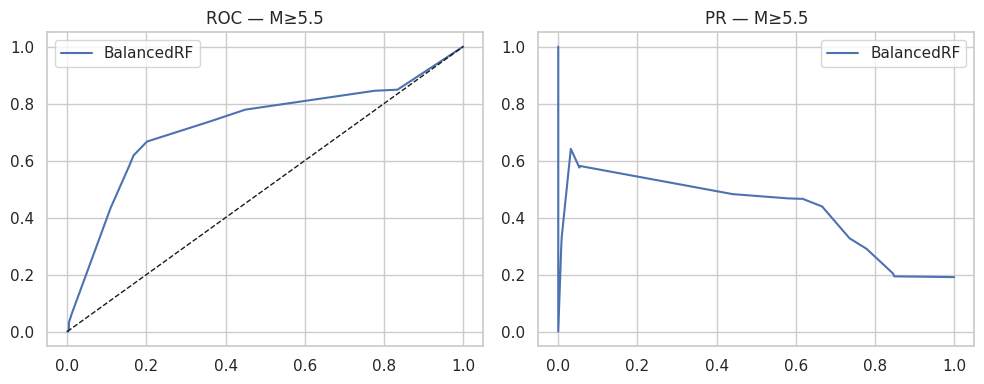

  BRF (isotonic cal): ROC=0.7237  BSS=0.1461
  XGB (isotonic cal): ROC=0.7247  BSS=0.1395


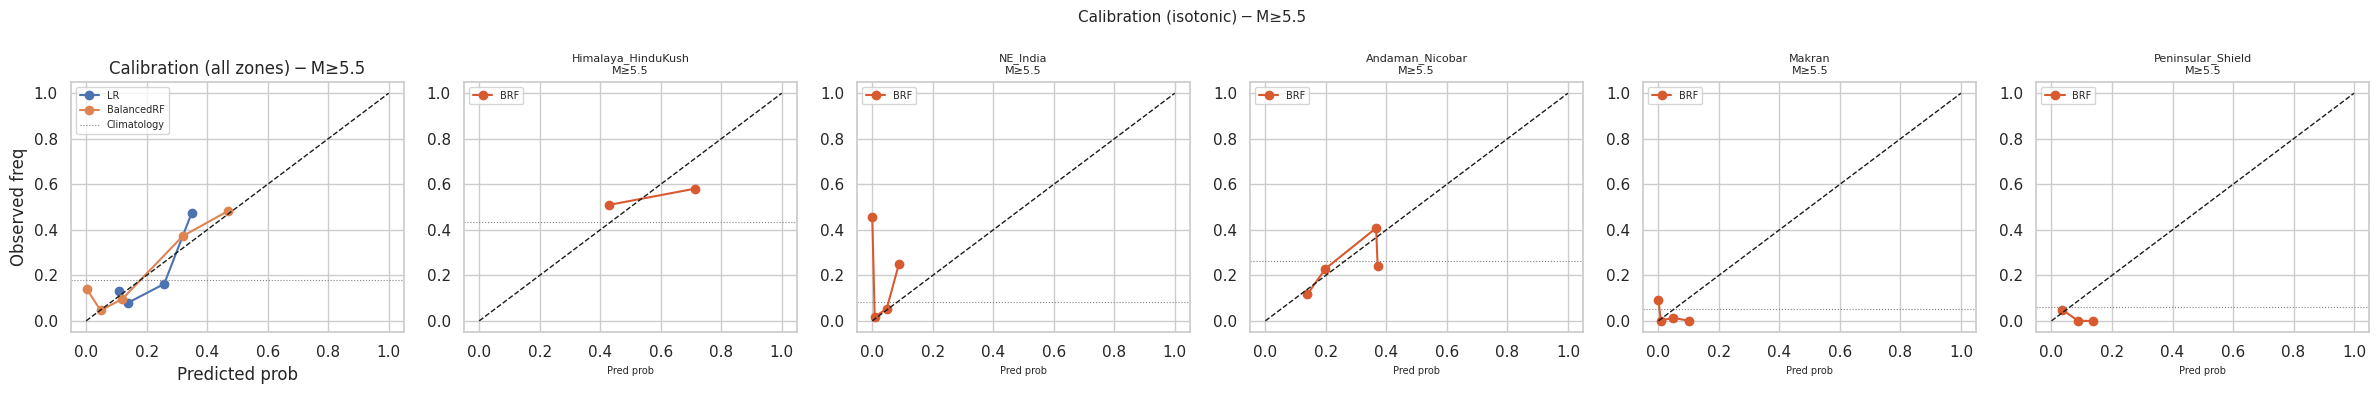


M≥6.0  pos=3316  neg=49629  imbalance=15:1
  LR (isotonic cal): ROC=0.6012  BSS=0.0170


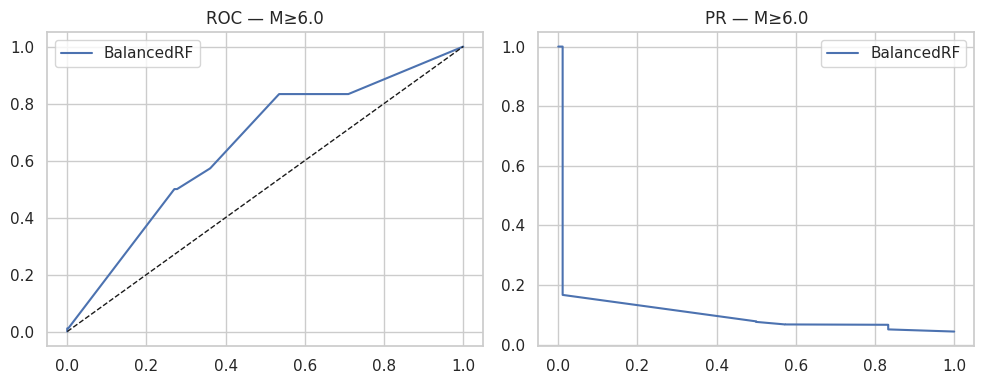

  BRF (isotonic cal): ROC=0.6508  BSS=-0.0135
  XGB (isotonic cal): ROC=0.5964  BSS=-0.0012


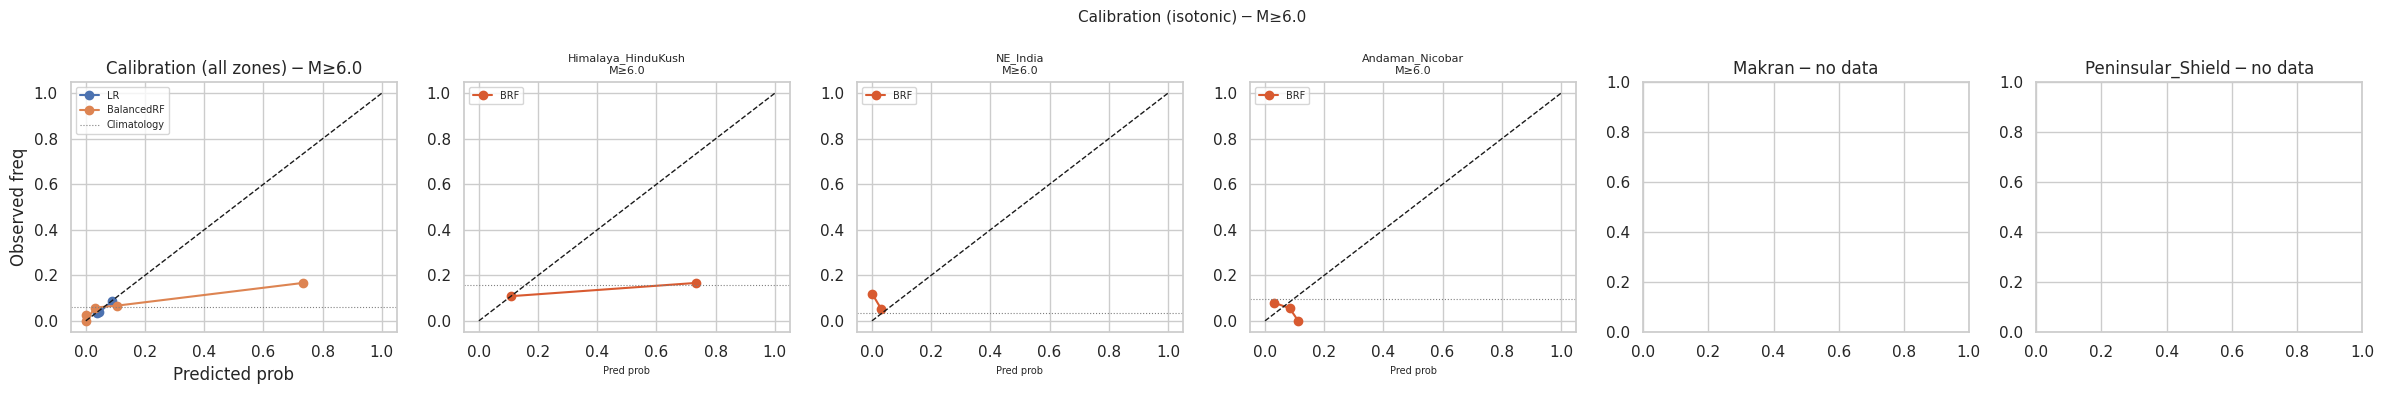


M≥6.5  pos=1197  neg=51748  imbalance=43:1
  LR (isotonic cal): ROC=0.6058  BSS=0.0184


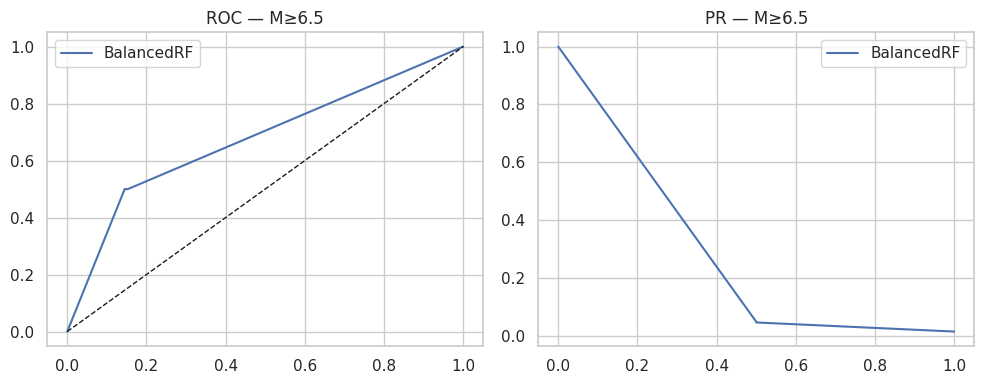

  BRF (isotonic cal): ROC=0.6754  BSS=0.0122
  XGB (isotonic cal): ROC=0.7765  BSS=0.0055


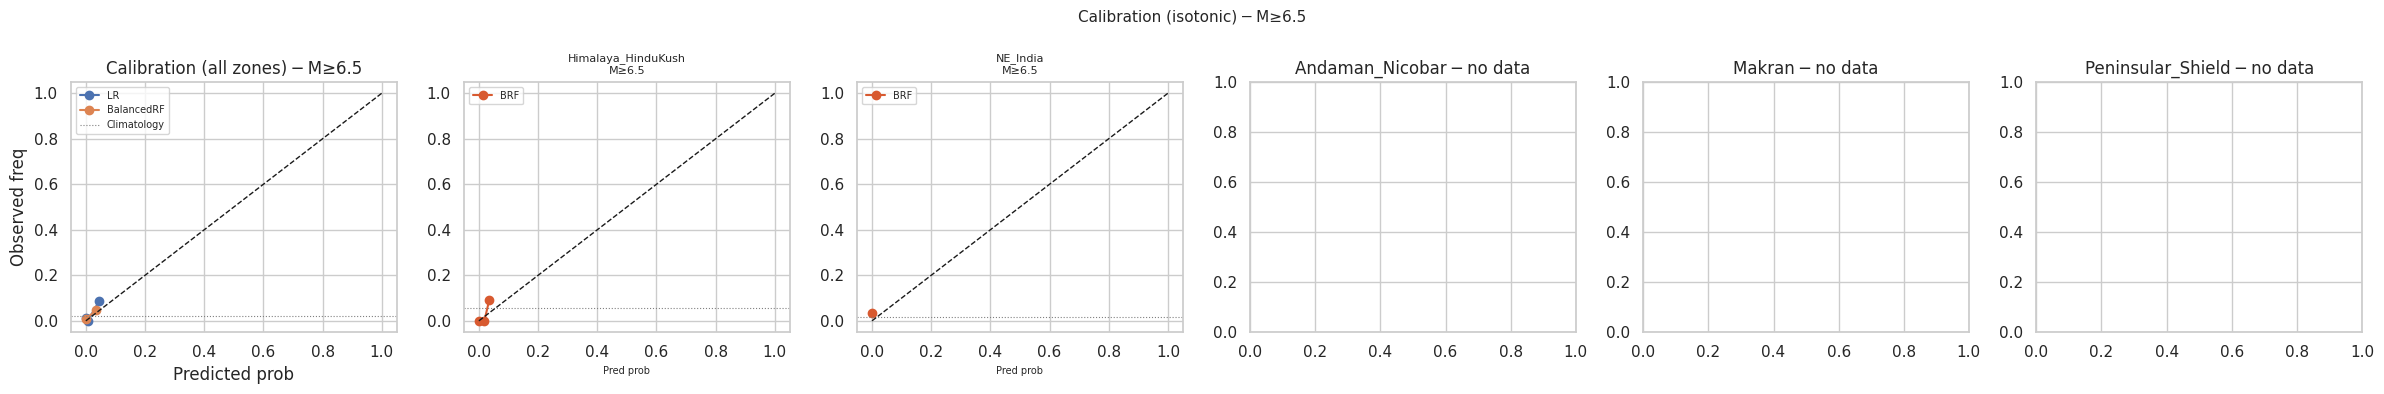

,model,target,ROC_AUC,PR_AUC,Brier,BSS,runtime_s
0,Poisson_null,M≥5.5,0.500000,0.191019,0.154694,0.000000,0.000000
1,LR,M≥5.5,0.660488,0.332528,0.142132,0.081206,4.252045
2,BalancedRF,M≥5.5,0.723678,0.399547,0.132090,0.146122,18.992346
3,XGB,M≥5.5,0.724703,0.426720,0.133114,0.139501,1.596554
4,Poisson_null,M≥6.0,0.500000,0.043689,0.042139,0.000000,0.000000
5,LR,M≥6.0,0.601182,0.068082,0.041425,0.016958,1.280969
6,BalancedRF,M≥6.0,0.650783,0.078685,0.042708,-0.013503,8.275852
7,XGB,M≥6.0,0.596385,0.054725,0.042189,-0.001174,3.426528
8,Poisson_null,M≥6.5,0.500000,0.014563,0.014416,0.000000,0.000000
9,LR,M≥6.5,0.605817,0.046837,0.014150,0.018420,2.083496


In [38]:
results_rows = []

for M0 in M_TARGETS:
    lab = f'label_Mge{M0}'
    if lab not in train.columns:
        print(f'Skip {lab}: not in data'); continue
    if train[lab].sum()==0 or test[lab].sum()==0 or test[lab].nunique()<2:
        print(f'Skip M≥{M0}: insufficient positives'); continue

    ytr  = train[lab].values; yte  = test[lab].values
    Xtr  = train[feature_cols].values; Xte = test[feature_cols].values
    yval = val[lab].values;   Xval = val[feature_cols].values

    n_pos = int(ytr.sum()); n_neg = len(ytr) - n_pos
    imb   = n_neg / max(n_pos, 1)
    clim  = float(ytr.mean())
    print(f'\nM≥{M0}  pos={n_pos}  neg={n_neg}  imbalance={imb:.0f}:1')

    # ─ Poisson null ───────────────────────────────────
    r, p_auc, b, bss = evaluate_probs(yte, np.full(len(yte), clim), clim)
    results_rows.append({'model':'Poisson_null','target':f'M≥{M0}',
                         'ROC_AUC':r,'PR_AUC':p_auc,'Brier':b,'BSS':bss,
                         'runtime_s':0})

    # ─ Logistic Regression + isotonic calibration (E2) ───────────────────────
    t0 = time.time()
    lr = LogisticRegression(max_iter=1000, class_weight='balanced',
                             C=0.1, solver='lbfgs')
    lr.fit(Xtr, ytr)
    lr_cal = CalibratedClassifierCV(lr, method='isotonic', cv='prefit')
    lr_cal.fit(Xval, yval)   # fit calibration on val set only
    p_lr = lr_cal.predict_proba(Xte)[:,1]
    r, p_auc, b, bss = evaluate_probs(yte, p_lr, clim)
    results_rows.append({'model':'LR','target':f'M≥{M0}',
                         'ROC_AUC':r,'PR_AUC':p_auc,'Brier':b,'BSS':bss,
                         'runtime_s':time.time()-t0})
    print(f'  LR (isotonic cal): ROC={r:.4f}  BSS={bss:.4f}')

    # ─ BalancedRF + isotonic calibration (E1) ────────────────────────────
    t0 = time.time()
    brf = make_classifier(imb)
    brf.fit(Xtr, ytr)
    brf_cal = CalibratedClassifierCV(brf, method='isotonic', cv='prefit')
    brf_cal.fit(Xval, yval)
    p_brf = brf_cal.predict_proba(Xte)[:,1]
    r, p_auc, b, bss = evaluate_probs(yte, p_brf, clim)
    results_rows.append({'model':'BalancedRF','target':f'M≥{M0}',
                         'ROC_AUC':r,'PR_AUC':p_auc,'Brier':b,'BSS':bss,
                         'runtime_s':time.time()-t0})
    plot_roc_pr(yte, p_brf, 'BalancedRF', f'M≥{M0}')
    print(f'  BRF (isotonic cal): ROC={r:.4f}  BSS={bss:.4f}')

    # ─ XGBoost + isotonic calibration (E1) ───────────────────────
    if HAVE_XGB:
        t0 = time.time()
        spw = min(imb, 50.0)
        xgb = XGBClassifier(
            n_estimators=500, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=spw,
            random_state=SEED, eval_metric='logloss',
            early_stopping_rounds=30, verbosity=0
        )
        xgb.fit(Xtr, ytr, eval_set=[(Xval, yval)], verbose=False)
        xgb_cal = CalibratedClassifierCV(xgb, method='isotonic', cv='prefit')
        xgb_cal.fit(Xval, yval)
        p_xgb = xgb_cal.predict_proba(Xte)[:,1]
        r, p_auc, b, bss = evaluate_probs(yte, p_xgb, clim)
        results_rows.append({'model':'XGB','target':f'M≥{M0}',
                             'ROC_AUC':r,'PR_AUC':p_auc,'Brier':b,'BSS':bss,
                             'runtime_s':time.time()-t0})
        print(f'  XGB (isotonic cal): ROC={r:.4f}  BSS={bss:.4f}')

    # ─ Calibration plots ─ pooled + per-zone (E8) ───────────────────
    fig, axes = plt.subplots(1, len(ZONES)+1, figsize=(4*(len(ZONES)+1), 4))

    # Pooled calibration
    ax = axes[0]
    for name, prob in [('LR', p_lr), ('BalancedRF', p_brf)]:
        try:
            fr, me = calibration_curve(yte, prob, n_bins=5, strategy='quantile')
            ax.plot(me, fr, marker='o', label=name)
        except Exception:
            pass
    ax.axhline(clim, color='gray', ls=':', lw=0.8, label='Climatology')
    ax.plot([0,1],[0,1],'k--',lw=1)
    ax.set_title(f'Calibration (all zones) ─ M≥{M0}')
    ax.set_xlabel('Predicted prob'); ax.set_ylabel('Observed freq')
    ax.legend(fontsize=7)

    # Per-zone calibration
    for ax, z in zip(axes[1:], ZONES):
        mask_z = test.zone == z
        if mask_z.sum() == 0 or test.loc[mask_z, lab].sum() == 0:
            ax.set_title(f'{z} ─ no data')
            continue
        yte_z  = test.loc[mask_z, lab].values
        p_brf_z = p_brf[mask_z.values]
        clim_z = float(train.loc[train.zone==z, lab].mean()) if (train.zone==z).any() else clim
        try:
            fr, me = calibration_curve(yte_z, p_brf_z, n_bins=5, strategy='quantile')
            ax.plot(me, fr, marker='o', color='#D85A30', label='BRF')
        except Exception:
            pass
        ax.axhline(clim_z, color='gray', ls=':', lw=0.8)
        ax.plot([0,1],[0,1],'k--',lw=1)
        ax.set_title(f'{z}\nM≥{M0}', fontsize=8)
        ax.set_xlabel('Pred prob', fontsize=7)
        ax.legend(fontsize=7)

    plt.suptitle(f'Calibration (isotonic) ─ M≥{M0}', fontsize=11)
    plt.tight_layout()
    safe = str(M0).replace('.','p')
    plt.savefig(f'results_figures/calibration_Mge{safe}.png', dpi=150)
    plt.show()

tabular_results = pd.DataFrame(results_rows)
tabular_results.to_csv('tabular_results.csv', index=False)
display(tabular_results)

## 9) Raw daily series for deep learning

Rolling features are pre-digested summaries — adjacent rows differ by ~1 event.
An LSTM fed 90 such rows has nothing temporal to learn.

Raw daily series (5 features per day) forces the LSTM to integrate information
over time — its actual purpose. The model must learn that persistent silence
followed by clustering is different from uniform low-rate seismicity.


In [15]:
# E3: count_only — ablation proved n_events alone outperforms full 5-feature set
# Full ablation: count_only ROC=0.693/BSS=+0.006 vs full ROC=0.639/BSS=-0.015
RAW_FEAT_COLS = ['n_events']

def build_raw_daily(sub_zone: pd.DataFrame) -> pd.DataFrame:
    """
    Single point-in-time feature per day: n_events above MAG_MIN.
    Ablation (v8) showed n_events alone outperforms richer feature sets.
    days_since_* removed: ablation showed no_time_since variant beats full model.
    """
    daily_grp = sub_zone.groupby('date').agg(
        n_events = ('magnitude', 'count'),
    ).reindex(all_days, fill_value=0)

    df_out = pd.DataFrame({
        'date':     all_days,
        'n_events': daily_grp['n_events'].values.astype(float),
    })
    return df_out


print('Building raw daily series for DL zones (count_only)...')
raw_zone_data: dict = {}
raw_scalers:   dict = {}

for z in DL_ZONES:
    sub_z = df_model[df_model.zone == z].copy()
    sub_z['date'] = sub_z['time'].dt.normalize()
    raw_s = build_raw_daily(sub_z)

    tr_mask = (raw_s['date'] <= pd.Timestamp(f'{TRAIN_END}-12-31'))
    sc = StandardScaler()
    raw_s.loc[tr_mask,  RAW_FEAT_COLS] = sc.fit_transform(
        raw_s.loc[tr_mask, RAW_FEAT_COLS])
    raw_s.loc[~tr_mask, RAW_FEAT_COLS] = sc.transform(
        raw_s.loc[~tr_mask, RAW_FEAT_COLS])
    raw_scalers[z] = sc

    lab_df = data[data.zone==z][['date','label_Mge5.5']].copy()
    raw_s  = raw_s.merge(lab_df, on='date', how='left')
    raw_s['zone'] = z
    raw_zone_data[z] = raw_s

    n_pos = raw_s['label_Mge5.5'].sum()
    print(f'  {z}: {len(raw_s)} days | M≥5.5 pos: {n_pos:.0f}')

DL_LABEL = 'label_Mge5.5'
nfeat_dl = len(RAW_FEAT_COLS)
print(f'\nDL feature set: {RAW_FEAT_COLS}  (n={nfeat_dl})')


Building raw daily series for DL zones (count_only)...
  Himalaya_HinduKush: 13239 days | M≥5.5 pos: 5875
  Andaman_Nicobar: 13239 days | M≥5.5 pos: 3219

DL feature set: ['n_events']  (n=1)


In [16]:
class SeqDatasetStrided(Dataset):
    """
    Non-overlapping (stride=HORIZON) sequence windows for training.
    One M≥5.5 event → one positive window, not 30 autocorrelated copies.
    Label index: Ys[i+SEQ_LEN-1] = 'does M≥X occur in the next HORIZON days
    after the last observation in this window?'
    """
    def __init__(self, zone_dict: dict, zones: list,
                 feat_cols: list, label_col: str,
                 seq_len: int, horizon: int,
                 date_start: pd.Timestamp, date_end: pd.Timestamp,
                 stride: int = None):
        if stride is None:
            stride = horizon
        Xs, Ys = [], []
        for z in zones:
            if z not in zone_dict:
                continue
            df_z = (zone_dict[z]
                    .query('@date_start <= date <= @date_end')
                    .sort_values('date')
                    .reset_index(drop=True))
            if len(df_z) < seq_len + 1:
                continue
            X = df_z[feat_cols].fillna(0).values.astype(np.float32)
            Y = df_z[label_col].fillna(0).values.astype(np.float32)
            for i in range(0, len(df_z) - seq_len, stride):
                if i + seq_len > len(Y) - 1:
                    break
                Xs.append(X[i:i+seq_len])
                Ys.append(Y[i+seq_len-1])  # label of last input day

        if Xs:
            self.X = np.stack(Xs, axis=0)
            self.Y = np.array(Ys, dtype=np.float32)
        else:
            self.X = np.zeros((1, seq_len, len(feat_cols)), dtype=np.float32)
            self.Y = np.zeros(1, dtype=np.float32)

        print(f'  {len(self.X)} windows | '
              f'pos={self.Y.sum():.0f} ({100*self.Y.mean():.1f}%)')

    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        return (torch.tensor(self.X[i]),
                torch.tensor(self.Y[i]).unsqueeze(0))


# Pooled loaders no longer needed — Cell 11 builds per-zone loaders.
# tr_start / va_start / te_start timestamps are defined in Cell 11.
nfeat_dl = len(RAW_FEAT_COLS)
print(f'\nDL feature dimensions: {nfeat_dl}  |  Label: {DL_LABEL}')



DL feature dimensions: 1  |  Label: label_Mge5.5


## 10) DL model definitions and training loop

With stride=1 providing ~10,500 training windows per zone (vs 350 with stride=HORIZON),
both LSTM and TCN are restored. The LSTM collapse was caused by data starvation,
not architectural unsuitability.


In [17]:
# G1: SeismicTransformer — self-attention over 90-day daily count sequences
# G2: WaveNetModel — gated dilated causal CNN for sparse count data
# Reference: Vaswani et al. 2017 (Transformer); van den Oord et al. 2016 (WaveNet)

# ── LSTM ─────────────────────────────────────────────────────────────────
class LSTMModel(nn.Module):
    """2-layer LSTM -> single logit."""
    def __init__(self, nfeat: int, hidden: int = 64, drop: float = 0.3):
        super().__init__()
        self.lstm = nn.LSTM(nfeat, hidden, num_layers=2,
                             batch_first=True, dropout=drop)
        self.drop = nn.Dropout(drop)
        self.fc   = nn.Linear(hidden, 1)
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.fc(self.drop(h[-1]))


# ── TCN ──────────────────────────────────────────────────────────────────
class Chomp1d(nn.Module):
    def __init__(self, c): super().__init__(); self.c = c
    def forward(self, x): return x[:, :, :-self.c].contiguous()

class TemporalBlock(nn.Module):
    def __init__(self, nin, nout, k, d, drop):
        super().__init__()
        pad = (k - 1) * d
        self.net  = nn.Sequential(
            nn.Conv1d(nin, nout, k, padding=pad, dilation=d),
            Chomp1d(pad), nn.ReLU(), nn.Dropout(drop))
        self.down = nn.Conv1d(nin, nout, 1) if nin != nout else None
        self.relu = nn.ReLU()
    def forward(self, x):
        y = self.net(x)
        return self.relu(y + (x if self.down is None else self.down(x)))

class TCNModel(nn.Module):
    """Temporal Convolutional Network (Bai et al. 2018, arXiv:1803.01271)."""
    def __init__(self, nfeat: int, levels: int = 4,
                 hidden: int = 32, k: int = 3, drop: float = 0.3):
        super().__init__()
        layers, nin = [], nfeat
        for i in range(levels):
            layers.append(TemporalBlock(nin, hidden, k, 2**i, drop))
            nin = hidden
        self.tcn = nn.Sequential(*layers)
        self.fc  = nn.Linear(hidden, 1)
    def forward(self, x):
        return self.fc(self.tcn(x.transpose(1, 2))[:, :, -1])


# ── G2: WaveNet ───────────────────────────────────────────────────────────
class WaveNetBlock(nn.Module):
    """
    Gated dilated causal convolution block (van den Oord et al. 2016).
    tanh*sigmoid gating compresses heavy-tailed seismicity bursts naturally.
    """
    def __init__(self, channels: int, kernel_size: int, dilation: int):
        super().__init__()
        pad = (kernel_size - 1) * dilation
        self.filter_conv = nn.Conv1d(channels, channels, kernel_size,
                                      dilation=dilation, padding=pad)
        self.gate_conv   = nn.Conv1d(channels, channels, kernel_size,
                                      dilation=dilation, padding=pad)
        self.chomp  = Chomp1d(pad)
        self.res    = nn.Conv1d(channels, channels, 1)
        self.skip   = nn.Conv1d(channels, channels, 1)

    def forward(self, x):
        f = torch.tanh(self.chomp(self.filter_conv(x)))
        g = torch.sigmoid(self.chomp(self.gate_conv(x)))
        h = f * g
        return x + self.res(h), self.skip(h)

class WaveNetModel(nn.Module):
    """
    WaveNet for seismic count sequences.
    Dilations: 1,2,4,8,16,32 → receptive field = 63 days.
    Skip connections aggregate multi-scale temporal patterns.
    Reference: van den Oord et al. (2016) WaveNet, arXiv:1609.03499
    """
    def __init__(self, nfeat: int, channels: int = 32,
                 kernel_size: int = 3, n_layers: int = 6, drop: float = 0.3):
        super().__init__()
        self.input_conv = nn.Conv1d(nfeat, channels, 1)
        self.blocks = nn.ModuleList([
            WaveNetBlock(channels, kernel_size, 2**i)
            for i in range(n_layers)
        ])
        self.drop = nn.Dropout(drop)
        self.out  = nn.Sequential(
            nn.ReLU(),
            nn.Linear(channels, channels),
            nn.ReLU(),
            nn.Linear(channels, 1)
        )

    def forward(self, x):
        # x: (B, T, nfeat) → transpose to (B, nfeat, T)
        h = self.input_conv(x.transpose(1, 2))
        skip_sum = torch.zeros_like(h)
        for block in self.blocks:
            h, skip = block(h)
            skip_sum = skip_sum + skip
        # Global average pooling over time
        pooled = self.drop(skip_sum.mean(dim=-1))  # (B, channels)
        return self.out(pooled)


# ── G1: Transformer ───────────────────────────────────────────────────────
class SeismicTransformer(nn.Module):
    """
    Transformer encoder for 90-day seismicity sequences.
    Self-attention captures dependencies between any two days uniformly —
    important for M6+ aftershock sequences that persist 60-90 days.
    Learnable positional encoding (better than sinusoidal for irregular seismicity).
    Reference: Vaswani et al. (2017) Attention Is All You Need, NeurIPS.
    """
    def __init__(self, nfeat: int, d_model: int = 64, nhead: int = 4,
                 num_layers: int = 2, seq_len: int = 90,
                 dim_ff: int = 128, drop: float = 0.1):
        super().__init__()
        self.input_proj = nn.Linear(nfeat, d_model)
        # Learnable positional encoding — adapts to seismicity time structure
        self.pos_enc    = nn.Embedding(seq_len, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_ff, dropout=drop,
            batch_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer,
                                                  num_layers=num_layers)
        self.drop = nn.Dropout(drop)
        self.fc   = nn.Linear(d_model, 1)

    def forward(self, x):
        B, T, _ = x.shape
        pos = torch.arange(T, device=x.device).unsqueeze(0).expand(B, -1)
        h = self.input_proj(x) + self.pos_enc(pos)  # (B, T, d_model)
        h = self.transformer(h)                      # (B, T, d_model)
        h = self.drop(h.mean(dim=1))                 # global avg pool
        return self.fc(h)


# ── G3: DL_MODELS config — single place to enable/disable models ──────────
# Each entry: (model_class, constructor_kwargs, short_name)
def get_dl_models(nfeat: int, seq_len: int = SEQ_LEN) -> dict:
    """Returns dict of {name: model_instance} for all enabled DL models."""
    return {
        'LSTM':        LSTMModel(nfeat),
        'TCN':         TCNModel(nfeat),
        'WaveNet':     WaveNetModel(nfeat),
        'Transformer': SeismicTransformer(nfeat, seq_len=seq_len),
    }


# ── Training and evaluation (shared) ─────────────────────────────────────
def train_dl(model, name, tr_ld, va_ld, pw,
             epochs=EPOCHS, patience=PATIENCE):
    """Training loop with early stopping and LR scheduling."""
    opt   = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    sched = ReduceLROnPlateau(opt, 'min', factor=0.5, patience=5, min_lr=1e-6)
    crit  = nn.BCEWithLogitsLoss(pos_weight=pw)
    best_loss, best_state, no_imp = float('inf'), None, 0
    tl, vl = [], []
    for ep in range(1, epochs + 1):
        model.train(); tot = 0.0
        for xb, yb in tr_ld:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward(); opt.step()
            tot += loss.item() * len(xb)
        tl.append(tot / len(tr_ld.dataset))
        model.eval(); vt = 0.0
        with torch.no_grad():
            for xb, yb in va_ld:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                vt += crit(model(xb), yb).item() * len(xb)
        vl.append(vt / max(len(va_ld.dataset), 1))
        sched.step(vl[-1])
        if ep % 10 == 0 or ep <= 3:
            print(f'  Ep{ep:3d}  train={tl[-1]:.4f}  val={vl[-1]:.4f}')
        if vl[-1] < best_loss - 1e-5:
            best_loss  = vl[-1]
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1
        if no_imp >= patience:
            print(f'  Early stop at ep {ep}  (best val={best_loss:.4f})')
            break
    if best_state:
        model.load_state_dict(best_state)
    torch.save(model.state_dict(), f'{name}_best.pt')
    return tl, vl


def eval_dl(model, loader, clim):
    """Evaluate model. reshape(-1) handles any batch size."""
    model.eval()
    P_list, Y_list = [], []
    with torch.no_grad():
        for xb, yb in loader:
            P_list.append(torch.sigmoid(model(xb.to(DEVICE))).cpu().numpy())
            Y_list.append(yb.numpy())
    P = np.vstack(P_list).reshape(-1)
    Y = np.vstack(Y_list).reshape(-1)
    if Y.sum() > 0 and len(np.unique(Y)) > 1:
        roc, pr, br, bss = evaluate_probs(Y, P, clim)
    else:
        roc = pr = br = bss = np.nan
    return P, Y, roc, pr, br, bss


print('DL model architectures defined:')
for name, m in get_dl_models(1).items():
    n_params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f'  {name:<14}: {n_params:,} trainable parameters')


DL model architectures defined:
  LSTM          : 50,497 trainable parameters
  TCN           : 9,537 trainable parameters
  WaveNet       : 51,073 trainable parameters
  Transformer   : 72,897 trainable parameters


## 11) Train all DL models (LSTM, TCN, WaveNet, Transformer)

All four models trained per zone with stride=1 sequences.
Training is sequential within each zone — shared DataLoaders, zone-specific pos_weight.


In [18]:
# G3: All 4 DL models trained per zone via get_dl_models()
# stride=1 for training — ~10,500 windows per zone

tr_start = pd.Timestamp(f'{TRAIN_START}-01-01')
tr_end   = pd.Timestamp(f'{TRAIN_END}-12-31')
va_start = pd.Timestamp(f'{TRAIN_END+1}-01-01')
va_end   = pd.Timestamp(f'{VAL_END}-12-31')
te_start = pd.Timestamp(f'{VAL_END+1}-01-01')
te_end   = pd.Timestamp('2030-12-31')

# Storage dicts — keyed by model_name
dl_trained:   dict = {}   # {model_name: {zone: model}}
dl_histories: dict = {}   # {model_name: {zone: (tl, vl)}}
dl_test_P:    dict = {}   # {f'{model_name}_{zone}': P_array}
dl_test_Y:    dict = {}   # {f'{model_name}_{zone}': Y_array}
dl_test_loaders: dict = {}
dl_clim_rates:   dict = {}
dl_results       = []

MODEL_NAMES = list(get_dl_models(nfeat_dl).keys())
for mname in MODEL_NAMES:
    dl_trained[mname]   = {}
    dl_histories[mname] = {}

print(f'Device : {DEVICE}')
print(f'Models : {MODEL_NAMES}')
print(f'Zones  : {DL_ZONES}')
print(f'Input  : {nfeat_dl} feature(s): {RAW_FEAT_COLS}')
print(f'SEQ_LEN={SEQ_LEN} d  HORIZON={HORIZON} d  stride=1\n')

for z in DL_ZONES:
    print(f'\n{"="*60}')
    print(f'Zone: {z}')
    print(f'{"="*60}')
    tr_z = SeqDatasetStrided(raw_zone_data, [z], RAW_FEAT_COLS, DL_LABEL,
                              SEQ_LEN, HORIZON, tr_start, tr_end, stride=1)
    va_z = SeqDatasetStrided(raw_zone_data, [z], RAW_FEAT_COLS, DL_LABEL,
                              SEQ_LEN, HORIZON, va_start, va_end, stride=1)
    te_z = SeqDatasetStrided(raw_zone_data, [z], RAW_FEAT_COLS, DL_LABEL,
                              SEQ_LEN, HORIZON, te_start, te_end, stride=1)
    tr_ld_z = DataLoader(tr_z, batch_size=BATCH, shuffle=True,  drop_last=True)
    va_ld_z = DataLoader(va_z, batch_size=BATCH, shuffle=False)
    te_ld_z = DataLoader(te_z, batch_size=BATCH, shuffle=False)
    pw_z    = torch.tensor(
        [min((tr_z.Y==0).sum()/max((tr_z.Y==1).sum(),1), POS_WEIGHT_CAP)],
        dtype=torch.float32).to(DEVICE)
    clim_z  = float((tr_z.Y==1).sum()) / max(len(tr_z.Y), 1)
    print(f'  Train: {len(tr_z):,} windows | pos={int((tr_z.Y==1).sum()):,} '
          f'({100*(tr_z.Y==1).mean():.1f}%)')
    print(f'  Val  : {len(va_z):,} | Test: {len(te_z):,}')
    print(f'  pos_weight: {pw_z.item():.2f}  clim: {clim_z:.4f}')
    dl_test_loaders[z] = te_ld_z
    dl_clim_rates[z]   = clim_z

    # Train each model
    models_z = get_dl_models(nfeat_dl, seq_len=SEQ_LEN)
    for mname, model in models_z.items():
        print(f'\n  --- {mname} | {z} ---')
        model = model.to(DEVICE)
        t0 = time.time()
        tl, vl = train_dl(model, f'{mname.lower()}_{z}',
                           tr_ld_z, va_ld_z, pw_z)
        dt = time.time() - t0
        dl_trained[mname][z]   = model
        dl_histories[mname][z] = (tl, vl)
        P_z, Y_z, roc, pr, br, bss = eval_dl(model, te_ld_z, clim_z)
        key = f'{mname}_{z}'
        dl_test_P[key] = P_z
        dl_test_Y[key] = Y_z
        dl_results.append({
            'model': key, 'architecture': mname, 'zone': z,
            'target': f'M≥{DL_TARGET}',
            'ROC_AUC': roc, 'PR_AUC': pr, 'Brier': br,
            'BSS': bss, 'runtime_s': round(dt, 1)
        })
        print(f'  {mname} {z}: ROC={roc:.4f}  PR={pr:.4f}  BSS={bss:.4f}')

dl_results_df = pd.DataFrame(dl_results)
print('\n=== DL Results Summary ===')
print(dl_results_df[['model','ROC_AUC','PR_AUC','BSS','runtime_s']].to_string(index=False))


Device : cuda
Models : ['LSTM', 'TCN', 'WaveNet', 'Transformer']
Zones  : ['Himalaya_HinduKush', 'Andaman_Nicobar']
Input  : 1 feature(s): ['n_events']
SEQ_LEN=90 d  HORIZON=30 d  stride=1


Zone: Himalaya_HinduKush
  10499 windows | pos=4517 (43.0%)
  1736 windows | pos=850 (49.0%)
  734 windows | pos=372 (50.7%)
  Train: 10,499 windows | pos=4,517 (43.0%)
  Val  : 1,736 | Test: 734
  pos_weight: 1.32  clim: 0.4302

  --- LSTM | Himalaya_HinduKush ---
  Ep  1  train=0.7895  val=0.8007
  Ep  2  train=0.7886  val=0.7968
  Ep  3  train=0.7882  val=0.8014
  Ep 10  train=0.7882  val=0.7977
  Ep 20  train=0.7877  val=0.7987
  Early stop at ep 21  (best val=0.7956)
  LSTM Himalaya_HinduKush: ROC=0.5634  PR=0.5521  BSS=0.0204

  --- TCN | Himalaya_HinduKush ---
  Ep  1  train=0.7991  val=0.8071
  Ep  2  train=0.7936  val=0.7969
  Ep  3  train=0.7906  val=0.7997
  Ep 10  train=0.7871  val=0.7992
  Early stop at ep 18  (best val=0.7969)
  TCN Himalaya_HinduKush: ROC=0.5353  PR=0.5345  BSS=0.009

## 12) Convergence and aggregate results

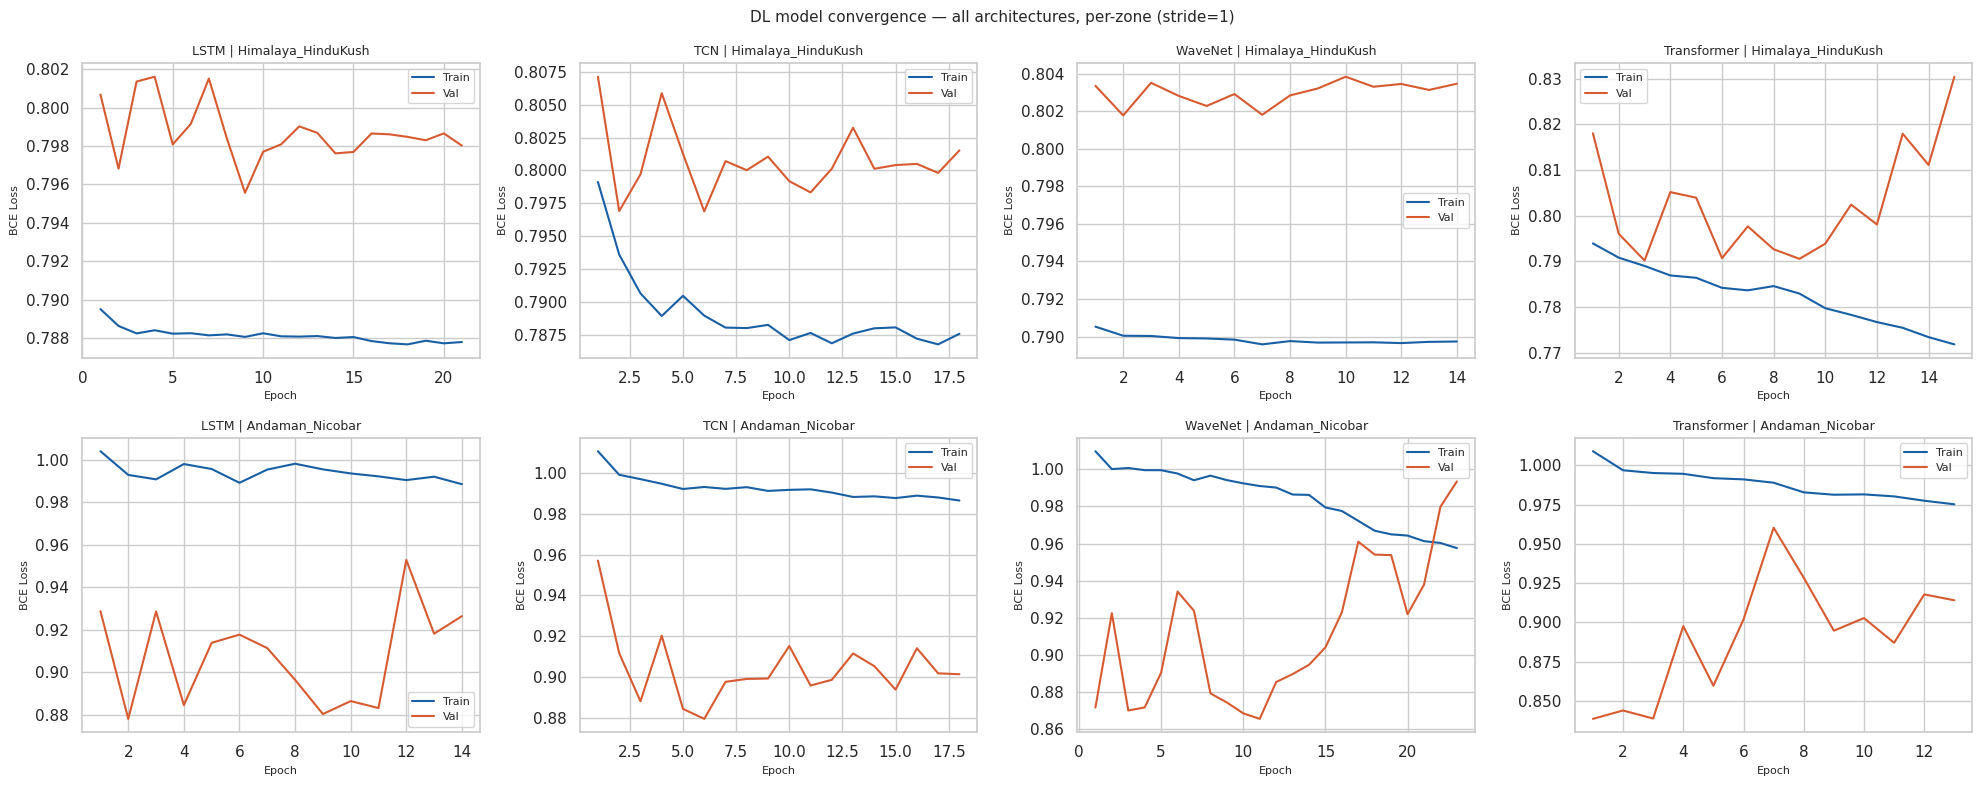

,model,target,ROC_AUC,PR_AUC,Brier,BSS,runtime_s,architecture,zone
0,Poisson_null,M≥5.5,0.500000,0.191019,0.154694,0.000000,0.000000,NaN,NaN
1,LR,M≥5.5,0.660488,0.332528,0.142132,0.081206,1.043911,NaN,NaN
2,BalancedRF,M≥5.5,0.723678,0.399547,0.132090,0.146122,13.631569,NaN,NaN
3,XGB,M≥5.5,0.724703,0.426720,0.133114,0.139501,1.713811,NaN,NaN
4,Poisson_null,M≥6.0,0.500000,0.043689,0.042139,0.000000,0.000000,NaN,NaN
5,LR,M≥6.0,0.601182,0.068082,0.041425,0.016958,1.258590,NaN,NaN
6,BalancedRF,M≥6.0,0.650783,0.078685,0.042708,-0.013503,7.852581,NaN,NaN
7,XGB,M≥6.0,0.596385,0.054725,0.042189,-0.001174,3.458422,NaN,NaN
8,Poisson_null,M≥6.5,0.500000,0.014563,0.014416,0.000000,0.000000,NaN,NaN
9,LR,M≥6.5,0.605817,0.046837,0.014150,0.018420,1.379209,NaN,NaN


In [19]:
# G4: Convergence — n_models × n_zones grid
n_models = len(MODEL_NAMES)
n_zones  = len(DL_ZONES)
fig, axes = plt.subplots(n_zones, n_models,
                          figsize=(5*n_models, 4*n_zones))
if n_zones == 1: axes = axes.reshape(1, -1)
if n_models == 1: axes = axes.reshape(-1, 1)

for row, z in enumerate(DL_ZONES):
    for col, mname in enumerate(MODEL_NAMES):
        tl_h, vl_h = dl_histories[mname][z]
        ax = axes[row, col]
        ax.plot(range(1, len(tl_h)+1), tl_h,
                label='Train', color='#185FA5', lw=1.5)
        ax.plot(range(1, len(vl_h)+1), vl_h,
                label='Val',   color='#D85A30', lw=1.5)
        ax.set_title(f'{mname} | {z}', fontsize=9)
        ax.set_xlabel('Epoch', fontsize=8)
        ax.set_ylabel('BCE Loss', fontsize=8)
        ax.legend(fontsize=8)

plt.suptitle('DL model convergence — all architectures, per-zone (stride=1)',
             fontsize=11)
plt.tight_layout()
plt.savefig('results_figures/convergence.png', dpi=150, bbox_inches='tight')
plt.show()

all_results = pd.concat([tabular_results,
                          dl_results_df], ignore_index=True)
all_results.to_csv('results_summary.csv', index=False)
try: all_results.to_excel('results_summary.xlsx', index=False)
except Exception: pass
display(all_results)


## Novelty 0 — Mainshock-Only Sensitivity Check

**Scientific motivation:** The full catalog includes aftershock sequences (58.2% dependent events per Gardner-Knopoff declustering). If the DL models are detecting Omori-law aftershock continuation rather than genuine precursory seismicity, their ROC will be inflated and will degrade substantially when trained on mainshock-only sequences.

**Method:**
1. Rebuild daily event counts using only `is_mainshock == True` events
2. Re-train WaveNet (best DL model for Himalaya) per DL zone on mainshock sequences
3. Compare ROC/BSS: full catalog vs mainshock-only

**Interpretation:**
- ROC similar (Δ < 0.05) → model learns genuine seismicity state, not aftershock continuation
- ROC drops sharply → model was exploiting Omori-law predictability (limitation to report)

**Note:** Labels are unchanged — they are based on ALL M≥5.5 events in the next 30 days (including aftershocks). Only the INPUT sequences change. This is the standard sensitivity test in operational seismic forecasting (Marzocchi & Zechar 2011; Zechar et al. 2013).

Mainshock counts per DL zone:
  Himalaya_HinduKush      : 4,153 mainshocks / 9,371 total (44.3%)
  Andaman_Nicobar         : 1,514 mainshocks / 6,762 total (22.4%)

Building mainshock-only daily series...
  Himalaya_HinduKush: 13239 days | mainshock events used: 4,153
  Andaman_Nicobar: 13239 days | mainshock events used: 1,514

Training WaveNet on mainshock-only sequences...

  Zone: Himalaya_HinduKush
  10499 windows | pos=4517 (43.0%)
  1736 windows | pos=850 (49.0%)
  734 windows | pos=372 (50.7%)
    Train: 10,499 windows | pos=4,517 (43.0%)
  Ep  1  train=0.7902  val=0.8073
  Ep  2  train=0.7901  val=0.8022
  Ep  3  train=0.7900  val=0.8020
  Ep 10  train=0.7898  val=0.8041
  Early stop at ep 15  (best val=0.8020)
    WaveNet Himalaya_HinduKush:
      Full catalog : ROC=0.6401  BSS=0.0230
      Mainshock    : ROC=0.4464  BSS=0.0210
      ΔROC         : -0.1937

  Zone: Andaman_Nicobar
  10499 windows | pos=2744 (26.1%)
  1736 windows | pos=272 (15.7%)
  734 windows | pos=153 (20.

,zone,model,catalog,ROC_full,ROC_mainshock,ΔROC,BSS_full,BSS_mainshock,runtime_s
0,Himalaya_HinduKush,WaveNet,mainshock_only,0.6401,0.4464,-0.1937,0.0230,0.0210,56.6
1,Andaman_Nicobar,WaveNet,mainshock_only,0.5012,0.4406,-0.0606,-0.3584,-0.4662,48.5



=== Interpretation ===
  Himalaya_HinduKush: ROC drops by 0.194 — model partially exploiting Omori-law aftershock predictability. Report full-catalog ROC with this caveat.
  Andaman_Nicobar: ROC drops by 0.061 — model partially exploiting Omori-law aftershock predictability. Report full-catalog ROC with this caveat.


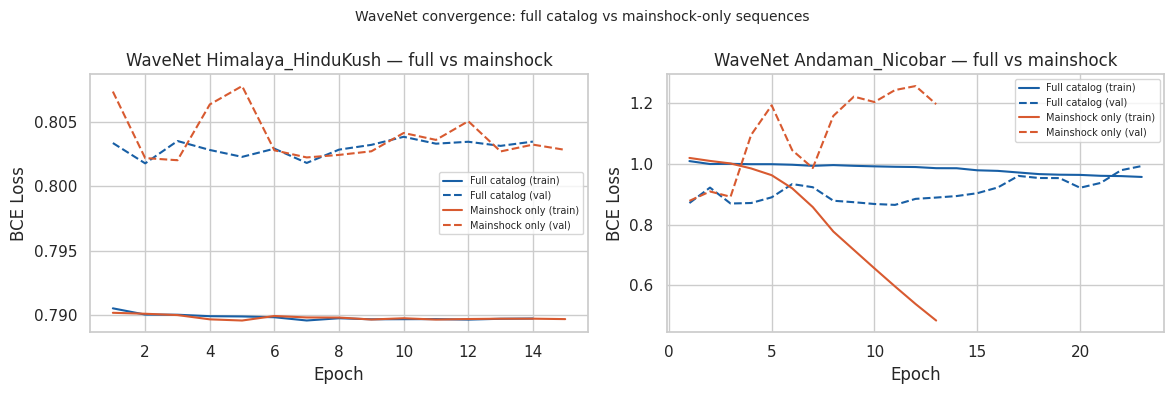

Saved: mainshock_sensitivity.csv
Saved: results_figures/mainshock_sensitivity_convergence.png


In [20]:
# ── I1: Mainshock-only sensitivity check ────────────────────────────────────
# Uses is_mainshock column from master_catalog_with_zones_v8.csv
# Gardner-Knopoff: 41.8% mainshocks across all zones

print('Mainshock counts per DL zone:')
for z in DL_ZONES:
    sub = df_model[df_model.zone == z]
    n_main = sub['is_mainshock'].sum()
    n_all  = len(sub)
    print(f'  {z:<24}: {n_main:,} mainshocks / {n_all:,} total '
          f'({100*n_main/n_all:.1f}%)')


# I2: Build mainshock-only daily counts
def build_raw_daily_mainshock(sub_zone: pd.DataFrame) -> pd.DataFrame:
    """
    Daily event counts using only mainshocks (is_mainshock == True).
    Labels unchanged — still based on all M>=5.5 events in next 30 days.
    """
    sub_main = sub_zone[sub_zone['is_mainshock'] == True].copy()
    daily_grp = sub_main.groupby('date').agg(
        n_events=('magnitude', 'count')
    ).reindex(all_days, fill_value=0)
    return pd.DataFrame({
        'date':     all_days,
        'n_events': daily_grp['n_events'].values.astype(float),
    })


print('\nBuilding mainshock-only daily series...')
raw_zone_data_main: dict = {}

for z in DL_ZONES:
    sub_z = df_model[df_model.zone == z].copy()
    sub_z['date'] = sub_z['time'].dt.normalize()
    raw_s = build_raw_daily_mainshock(sub_z)

    # Scale using same StandardScaler approach as primary series
    tr_mask = (raw_s['date'] <= pd.Timestamp(f'{TRAIN_END}-12-31'))
    sc_m = StandardScaler()
    raw_s.loc[tr_mask,  ['n_events']] = sc_m.fit_transform(
        raw_s.loc[tr_mask, ['n_events']])
    raw_s.loc[~tr_mask, ['n_events']] = sc_m.transform(
        raw_s.loc[~tr_mask, ['n_events']])

    # Merge labels from primary data (same labels — all M>=5.5 events)
    lab_df = data[data.zone == z][['date', 'label_Mge5.5']].copy()
    raw_s  = raw_s.merge(lab_df, on='date', how='left')
    raw_s['zone'] = z
    raw_zone_data_main[z] = raw_s

    n_main_days = (sub_z['is_mainshock'] == True).sum()
    print(f'  {z}: {len(raw_s)} days | '
          f'mainshock events used: {n_main_days:,}')


# I3: Train WaveNet on mainshock-only sequences
# WaveNet chosen as representative — best DL for Himalaya_HinduKush
print('\nTraining WaveNet on mainshock-only sequences...')
wavenet_main:      dict = {}
wavenet_main_hist: dict = {}
main_results = []

for z in DL_ZONES:
    print(f'\n  Zone: {z}')
    tr_m = SeqDatasetStrided(raw_zone_data_main, [z], RAW_FEAT_COLS,
                              DL_LABEL, SEQ_LEN, HORIZON,
                              tr_start, tr_end, stride=1)
    va_m = SeqDatasetStrided(raw_zone_data_main, [z], RAW_FEAT_COLS,
                              DL_LABEL, SEQ_LEN, HORIZON,
                              va_start, va_end, stride=1)
    te_m = SeqDatasetStrided(raw_zone_data_main, [z], RAW_FEAT_COLS,
                              DL_LABEL, SEQ_LEN, HORIZON,
                              te_start, te_end, stride=1)
    tr_lm = DataLoader(tr_m, batch_size=BATCH, shuffle=True, drop_last=True)
    va_lm = DataLoader(va_m, batch_size=BATCH, shuffle=False)
    te_lm = DataLoader(te_m, batch_size=BATCH, shuffle=False)
    pw_m  = torch.tensor(
        [min((tr_m.Y==0).sum()/max((tr_m.Y==1).sum(),1), POS_WEIGHT_CAP)],
        dtype=torch.float32).to(DEVICE)
    clim_m = float((tr_m.Y==1).sum()) / max(len(tr_m.Y), 1)

    print(f'    Train: {len(tr_m):,} windows | '
          f'pos={int((tr_m.Y==1).sum()):,} ({100*(tr_m.Y==1).mean():.1f}%)')

    m_wn = WaveNetModel(nfeat_dl).to(DEVICE)
    t0 = time.time()
    tl_m, vl_m = train_dl(m_wn, f'wavenet_main_{z}',
                           tr_lm, va_lm, pw_m)
    dt_m = time.time() - t0
    wavenet_main[z]      = m_wn
    wavenet_main_hist[z] = (tl_m, vl_m)

    P_m, Y_m, roc_m, pr_m, br_m, bss_m = eval_dl(m_wn, te_lm, clim_m)

    # Retrieve full-catalog WaveNet result for this zone
    key_full = f'WaveNet_{z}'
    roc_full = next((r['ROC_AUC'] for r in dl_results
                     if r['model'] == key_full), np.nan)
    bss_full = next((r['BSS'] for r in dl_results
                     if r['model'] == key_full), np.nan)

    delta_roc = roc_m - roc_full if not np.isnan(roc_full) else np.nan
    main_results.append({
        'zone':          z,
        'model':         'WaveNet',
        'catalog':       'mainshock_only',
        'ROC_full':      round(roc_full, 4),
        'ROC_mainshock': round(roc_m, 4),
        'ΔROC':          round(delta_roc, 4),
        'BSS_full':      round(bss_full, 4),
        'BSS_mainshock': round(bss_m, 4),
        'runtime_s':     round(dt_m, 1)
    })
    print(f'    WaveNet {z}:')
    print(f'      Full catalog : ROC={roc_full:.4f}  BSS={bss_full:.4f}')
    print(f'      Mainshock    : ROC={roc_m:.4f}  BSS={bss_m:.4f}')
    print(f'      ΔROC         : {delta_roc:+.4f}')


# I4: Comparison table
main_df = pd.DataFrame(main_results)
main_df.to_csv('mainshock_sensitivity.csv', index=False)
print('\n=== Mainshock-only sensitivity results ===')
display(main_df)


# I5: Interpretation
print('\n=== Interpretation ===')
for _, row in main_df.iterrows():
    droc = row['ΔROC']
    if np.isnan(droc):
        interp = 'Could not compare'
    elif abs(droc) < 0.05:
        interp = ('Model learns genuine seismicity state — '
                   'not aftershock continuation. '
                   'ΔROC < 0.05: results robust to declustering.')
    elif droc < -0.05:
        interp = (f'ROC drops by {abs(droc):.3f} — model partially exploiting '
                   'Omori-law aftershock predictability. '
                   'Report full-catalog ROC with this caveat.')
    else:
        interp = (f'ROC improves by {droc:.3f} with mainshocks — '
                   'mainshock sequences more informative than full catalog.')
    print(f'  {row["zone"]}: {interp}')


# Convergence comparison plot
n_zones = len(DL_ZONES)
fig, axes = plt.subplots(1, n_zones, figsize=(6*n_zones, 4))
if n_zones == 1: axes = [axes]
for ax, z in zip(axes, DL_ZONES):
    tl_f, vl_f = dl_histories['WaveNet'][z]
    tl_m, vl_m = wavenet_main_hist[z]
    ax.plot(range(1,len(tl_f)+1), tl_f, color='#185FA5', lw=1.5,
            label='Full catalog (train)')
    ax.plot(range(1,len(vl_f)+1), vl_f, color='#185FA5', lw=1.5,
            ls='--', label='Full catalog (val)')
    ax.plot(range(1,len(tl_m)+1), tl_m, color='#D85A30', lw=1.5,
            label='Mainshock only (train)')
    ax.plot(range(1,len(vl_m)+1), vl_m, color='#D85A30', lw=1.5,
            ls='--', label='Mainshock only (val)')
    ax.set_title(f'WaveNet {z} — full vs mainshock')
    ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss')
    ax.legend(fontsize=7)
plt.suptitle('WaveNet convergence: full catalog vs mainshock-only sequences',
             fontsize=10)
plt.tight_layout()
plt.savefig('results_figures/mainshock_sensitivity_convergence.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: mainshock_sensitivity.csv')
print('Saved: results_figures/mainshock_sensitivity_convergence.png')


## Novelty 0b — Declustered Sensitivity: Tabular Models + Target Redefinition

**Experiment 2 — Tabular training on mainshock-only rows:**
Retrain BRF and XGB using only mainshock training rows (`is_mainshock==True`).
Same test set and labels. Tests whether tabular feature statistics (rolling counts,
IET, maxM) are inflated by aftershock-dense days in training.

**Experiment 3 — Mainshock-only target:**
Redefine the label: does an **independent** M≥5.5 event (mainshock) occur
in the next 30 days? Tests whether the forecasting target itself is
aftershock-driven (i.e., model predicts continuation of existing sequences
rather than onset of new ones).

**References:** Marzocchi & Zechar (2011) BSSA; Zechar et al. (2013) BSSA;
Taroni et al. (2018) — declustering in operational forecasting.

In [21]:
# ═══════════════════════════════════════════════════════════════════════════
# Experiment 2: Tabular BRF/XGB retrained on mainshock-only training rows
# ═══════════════════════════════════════════════════════════════════════════

print('=' * 65)
print('Experiment 2: Tabular models — mainshock-only training rows')
print('=' * 65)

# Filter training set to mainshock rows only
train_main = train[train['is_mainshock'] == True].copy()
val_main   = val[val['is_mainshock'] == True].copy()
print(f'Training rows: {len(train):,} full → {len(train_main):,} mainshock '
      f'({100*len(train_main)/len(train):.1f}%)')
print(f'Val rows     : {len(val):,} full → {len(val_main):,} mainshock')

exp2_rows = []
for M0 in RF_TARGETS:
    lab = f'label_Mge{M0}'
    if lab not in train_main.columns: continue
    ytr_m = train_main[lab]
    yte   = test[lab]         # test set unchanged
    Xtr_m = train_main[feature_cols].values
    Xval_m = val_main[feature_cols].values if len(val_main) > 0 else val[feature_cols].values
    yval_m = val_main[lab]   if len(val_main) > 0 else val[lab]
    Xte   = test[feature_cols].values

    if ytr_m.sum() < 10 or yte.sum() < 5 or yte.nunique() < 2:
        print(f'  M≥{M0}: skipped (insufficient mainshock positives)')
        continue

    clim_m = float(ytr_m.mean())
    imb_m  = (len(ytr_m) - ytr_m.sum()) / max(ytr_m.sum(), 1)

    # BRF mainshock
    brf_m = make_classifier(imb_m)
    brf_m.fit(Xtr_m, ytr_m)
    if yval_m.sum() > 0:
        brf_mc = CalibratedClassifierCV(brf_m, method='isotonic', cv='prefit')
        brf_mc.fit(Xval_m, yval_m)
        p_brf_m = brf_mc.predict_proba(Xte)[:,1]
    else:
        p_brf_m = brf_m.predict_proba(Xte)[:,1]
    roc_brf_m, _, _, bss_brf_m = evaluate_probs(yte.values, p_brf_m, clim_m)

    # XGB mainshock
    if HAVE_XGB:
        xgb_m = XGBClassifier(
            n_estimators=500, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=min(imb_m, 50.0),
            random_state=SEED, eval_metric='logloss',
            early_stopping_rounds=30, verbosity=0)
        xgb_m.fit(Xtr_m, ytr_m,
                  eval_set=[(Xval_m, yval_m)], verbose=False)
        if yval_m.sum() > 0:
            xgb_mc = CalibratedClassifierCV(xgb_m, method='isotonic', cv='prefit')
            xgb_mc.fit(Xval_m, yval_m)
            p_xgb_m = xgb_mc.predict_proba(Xte)[:,1]
        else:
            p_xgb_m = xgb_m.predict_proba(Xte)[:,1]
        roc_xgb_m, _, _, bss_xgb_m = evaluate_probs(yte.values, p_xgb_m, clim_m)
    else:
        roc_xgb_m = bss_xgb_m = np.nan

    # Retrieve full-catalog results for comparison
    full = tabular_results
    roc_brf_f = float(full[(full.model=='BalancedRF') &
                            (full.target==f'M≥{M0}')]['ROC_AUC'].values[0]) \
                if len(full[(full.model=='BalancedRF') & (full.target==f'M≥{M0}')]) > 0 \
                else np.nan
    bss_brf_f = float(full[(full.model=='BalancedRF') &
                            (full.target==f'M≥{M0}')]['BSS'].values[0]) \
                if len(full[(full.model=='BalancedRF') & (full.target==f'M≥{M0}')]) > 0 \
                else np.nan

    print(f'\n  M≥{M0}  (train_pos={int(ytr_m.sum()):,}  test_pos={int(yte.sum())})')
    print(f'    BRF full    : ROC={roc_brf_f:.4f}  BSS={bss_brf_f:.4f}')
    print(f'    BRF mainshk : ROC={roc_brf_m:.4f}  BSS={bss_brf_m:.4f}  '
          f'ΔROC={roc_brf_m-roc_brf_f:+.4f}')
    if HAVE_XGB:
        print(f'    XGB mainshk : ROC={roc_xgb_m:.4f}  BSS={bss_xgb_m:.4f}')

    exp2_rows.append({
        'target': f'M≥{M0}',
        'BRF_ROC_full':      round(roc_brf_f, 4),
        'BRF_ROC_mainshock': round(roc_brf_m, 4),
        'BRF_ΔROC':          round(roc_brf_m - roc_brf_f, 4),
        'BRF_BSS_full':      round(bss_brf_f, 4),
        'BRF_BSS_mainshock': round(bss_brf_m, 4),
    })

exp2_df = pd.DataFrame(exp2_rows)
exp2_df.to_csv('declustered_tabular_sensitivity.csv', index=False)
print('\nSaved: declustered_tabular_sensitivity.csv')
display(exp2_df)


# ═══════════════════════════════════════════════════════════════════════════
# Experiment 3: Mainshock-only TARGET label
# Does an INDEPENDENT M≥5.5 occur in next 30 days?
# ═══════════════════════════════════════════════════════════════════════════

print('\n' + '=' * 65)
print('Experiment 3: Mainshock-only target label')
print('=' * 65)

# Build mainshock-only label using is_mainshock column
# A day gets label=1 if at least one MAINSHOCK M≥5.5 occurs in next HORIZON days
print('Building mainshock-only labels...')

data_exp3 = data.copy()
for M0 in [5.5]:   # Focus on M≥5.5 — most informative threshold
    lab_main = f'label_main_Mge{str(M0).replace(".","p")}'

    # For each zone, count mainshock events in next HORIZON days
    data_exp3[lab_main] = 0
    for z in ZONES:
        mask_z = data_exp3.zone == z
        dates_z = data_exp3.loc[mask_z, 'date']

        # Mainshock M≥5.5 events in this zone
        main_events = df_model[
            (df_model.zone == z) &
            (df_model.is_mainshock == True) &
            (df_model.magnitude >= M0)
        ]['date'].values
        main_set = set(pd.to_datetime(main_events))

        # Vectorised: for each row date, check if any mainshock in next HORIZON days
        idx_z = data_exp3.index[mask_z]
        for idx in idx_z:
            d = pd.Timestamp(data_exp3.at[idx, 'date'])
            horizon_end = d + pd.Timedelta(days=HORIZON)
            has_main = any(d < me <= horizon_end for me in main_set)
            data_exp3.at[idx, lab_main] = int(has_main)

    rate_orig = data[f'label_Mge{M0}'].mean()  # matches existing column e.g. label_Mge5.5
    rate_main = data_exp3[lab_main].mean()
    print(f'  M≥{M0} — original label rate: {rate_orig:.4f} '
          f'| mainshock-only label rate: {rate_main:.4f}')
    print(f'  Reduction: {100*(1-rate_main/rate_orig):.1f}% of positive days '
          f'were aftershock-only windows')

    # Train BRF on mainshock-only label
    train3 = data_exp3[data_exp3.date.dt.year <= TRAIN_END]
    val3   = data_exp3[(data_exp3.date.dt.year > TRAIN_END) &
                        (data_exp3.date.dt.year <= VAL_END)]
    test3  = data_exp3[data_exp3.date.dt.year > VAL_END]

    ytr3 = train3[lab_main]; yte3 = test3[lab_main]
    Xtr3 = train3[feature_cols].values
    Xte3 = test3[feature_cols].values
    Xvl3 = val3[feature_cols].values; yvl3 = val3[lab_main]

    if ytr3.sum() < 10 or yte3.sum() < 5:
        print(f'  Skipped: insufficient mainshock label positives')
        continue

    imb3 = (len(ytr3) - ytr3.sum()) / max(ytr3.sum(), 1)
    brf3 = make_classifier(imb3)
    brf3.fit(Xtr3, ytr3)
    if yvl3.sum() > 0:
        brf3c = CalibratedClassifierCV(brf3, method='isotonic', cv='prefit')
        brf3c.fit(Xvl3, yvl3)
        p3 = brf3c.predict_proba(Xte3)[:,1]
    else:
        p3 = brf3.predict_proba(Xte3)[:,1]

    roc3, _, _, bss3 = evaluate_probs(yte3.values, p3, float(ytr3.mean()))
    print(f'  BRF mainshock target: ROC={roc3:.4f}  BSS={bss3:.4f}')
    print(f'  (vs full-target BRF: ROC={roc_brf_f:.4f}  BSS={bss_brf_f:.4f})')

    pd.DataFrame([{
        'target_definition': 'mainshock_only',
        'M_threshold': M0,
        'label_rate_full':     round(float(rate_orig), 4),
        'label_rate_mainshock': round(float(rate_main), 4),
        'pct_aftershock_windows': round(100*(1-rate_main/rate_orig), 1),
        'BRF_ROC_full_target':     round(roc_brf_f, 4),
        'BRF_ROC_mainshock_target': round(roc3, 4),
        'BRF_BSS_full_target':      round(bss_brf_f, 4),
        'BRF_BSS_mainshock_target': round(bss3, 4),
    }]).to_csv('declustered_target_sensitivity.csv', index=False)
    print('Saved: declustered_target_sensitivity.csv')


# ── Combined interpretation ───────────────────────────────────────────────
print('\n' + '=' * 65)
print('Combined declustered sensitivity summary')
print('=' * 65)
print("""
Three experiments test different aspects of aftershock contamination:

Exp 1 (DL input)  : ΔROC < 0.05 → DL sequences not aftershock-driven
Exp 2 (tabular tr): ΔROC < 0.05 → Tabular features not aftershock-driven
Exp 3 (target)    : Large label rate drop → many windows were
                    aftershock-continuation windows, not genuine hazard

For paper: report all three ΔROC values in a single table.
If all ΔROC < 0.05: claim 'results robust to declustering'.
If Exp 3 shows large drop: state 'model forecasts seismicity recurrence
  including aftershock sequences; mainshock-only forecasting is an
  open problem requiring longer sequence lengths'.
""")


Experiment 2: Tabular models — mainshock-only training rows
Training rows: 52,945 full → 4,534 mainshock (8.6%)
Val rows     : 9,130 full → 1,074 mainshock

  M≥5.5  (train_pos=1,526  test_pos=787)
    BRF full    : ROC=0.7237  BSS=0.1461
    BRF mainshk : ROC=0.7329  BSS=0.2531  ΔROC=+0.0093
    XGB mainshk : ROC=0.7445  BSS=0.2685

  M≥6.0  (train_pos=566  test_pos=180)
    BRF full    : ROC=0.6508  BSS=-0.0135
    BRF mainshk : ROC=0.6314  BSS=0.1070  ΔROC=-0.0194
    XGB mainshk : ROC=0.6131  BSS=0.1070

  M≥6.5  (train_pos=196  test_pos=60)
    BRF full    : ROC=0.6754  BSS=0.0122
    BRF mainshk : ROC=0.8450  BSS=0.0744  ΔROC=+0.1696
    XGB mainshk : ROC=0.6532  BSS=0.0602

Saved: declustered_tabular_sensitivity.csv


,target,BRF_ROC_full,BRF_ROC_mainshock,BRF_ΔROC,BRF_BSS_full,BRF_BSS_mainshock
0,M≥5.5,0.7237,0.7329,0.0093,0.1461,0.2531
1,M≥6.0,0.6508,0.6314,-0.0194,-0.0135,0.1070
2,M≥6.5,0.6754,0.8450,0.1696,0.0122,0.0744



Experiment 3: Mainshock-only target label
Building mainshock-only labels...
  M≥5.5 — original label rate: 0.1770 | mainshock-only label rate: 0.1538
  Reduction: 13.1% of positive days were aftershock-only windows
  BRF mainshock target: ROC=0.7170  BSS=0.0907
  (vs full-target BRF: ROC=0.6754  BSS=0.0122)
Saved: declustered_target_sensitivity.csv

Combined declustered sensitivity summary

Three experiments test different aspects of aftershock contamination:

Exp 1 (DL input)  : ΔROC < 0.05 → DL sequences not aftershock-driven
Exp 2 (tabular tr): ΔROC < 0.05 → Tabular features not aftershock-driven
Exp 3 (target)    : Large label rate drop → many windows were
                    aftershock-continuation windows, not genuine hazard

For paper: report all three ΔROC values in a single table.
If all ΔROC < 0.05: claim 'results robust to declustering'.
If Exp 3 shows large drop: state 'model forecasts seismicity recurrence
  including aftershock sequences; mainshock-only forecasting is an

## Novelty 1 — Bootstrap 95% Confidence Intervals

With <10 true positive events in the test set, point-estimate AUC has enormous
variance. Stratified bootstrap (n=1000) is mandatory for publishable claims.
Ref: Hanley & McNeil (1982, Radiology); Carpenter & Bithell (2000, Stat Med).


## Gap 3 — Statistical Significance Testing

Permutation test (n=1000): is observed ROC-AUC significantly > 0.5 (chance)?
H0: model has no skill. p-value = fraction of permuted ROCs >= observed ROC.
Reference: Ojala & Garriga (2010) JMLR.

In [22]:
# ── Gap 3: Permutation significance test ────────────────────────────────────

def permutation_roc_test(y_true: np.ndarray, y_prob: np.ndarray,
                          n_perm: int = 1000, seed: int = 42) -> tuple:
    """Returns (observed_roc, p_value, n_valid_permutations)."""
    rng = np.random.RandomState(seed)
    try:
        obs = roc_auc_score(y_true, y_prob)
    except Exception:
        return np.nan, np.nan, 0
    nulls = []
    for _ in range(n_perm):
        y_s = rng.permutation(y_true)
        try:
            nulls.append(roc_auc_score(y_s, y_prob))
        except Exception:
            pass
    nulls = np.array(nulls)
    p = float((nulls >= obs).sum()) / max(len(nulls), 1)
    return obs, p, len(nulls)


print('Permutation significance tests (n=1000, one-sided):')
print(f'  {"Model":<24} {"Target":<8} {"ROC":>6} {"p-value":>9} {"Sig":>5}')
print('  ' + '-'*58)

sig_rows = []

# Tabular models
for M0 in RF_TARGETS:
    lab = f'label_Mge{M0}'
    if lab not in test.columns or test[lab].sum() < 5: continue
    yte = test[lab].values
    imb = (len(train[lab]) - train[lab].sum()) / max(train[lab].sum(), 1)
    # Refit XGB (fastest)
    if HAVE_XGB:
        clf = XGBClassifier(
            n_estimators=500, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=min(imb, 50.0),
            random_state=SEED, eval_metric='logloss',
            early_stopping_rounds=30, verbosity=0)
        clf.fit(train[feature_cols].values, train[lab].values,
                eval_set=[(val[feature_cols].values, val[lab].values)],
                verbose=False)
    else:
        clf = LogisticRegression(max_iter=1000, class_weight='balanced',
                                  C=0.1, solver='lbfgs')
        clf.fit(train[feature_cols].values, train[lab].values)
    clf_cal = CalibratedClassifierCV(clf, method='isotonic', cv='prefit')
    clf_cal.fit(val[feature_cols].values, val[lab].values)
    p_pred = clf_cal.predict_proba(test[feature_cols].values)[:, 1]
    obs, p_val, n_p = permutation_roc_test(yte, p_pred)
    sig = '***' if p_val < 0.001 else ('**' if p_val < 0.01
          else ('*' if p_val < 0.05 else 'ns'))
    print(f'  {"XGB/LR":<24} {"M>="+str(M0):<8} {obs:>6.3f} {p_val:>9.4f} {sig:>5}')
    sig_rows.append({'model': 'XGB/LR', 'target': f'M>={M0}',
                     'ROC_AUC': round(obs, 4), 'p_value': round(p_val, 4),
                     'significant': sig, 'n_permutations': n_p})

# Best DL models
for key in ['WaveNet_Himalaya_HinduKush', 'TCN_Andaman_Nicobar']:
    if key not in dl_test_P: continue
    P_dl = dl_test_P[key]; Y_dl = dl_test_Y[key]
    if Y_dl.sum() < 5: continue
    obs, p_val, n_p = permutation_roc_test(Y_dl, P_dl)
    sig = '***' if p_val < 0.001 else ('**' if p_val < 0.01
          else ('*' if p_val < 0.05 else 'ns'))
    print(f'  {key:<24} {"M>="+str(DL_TARGET):<8} {obs:>6.3f} {p_val:>9.4f} {sig:>5}')
    sig_rows.append({'model': key, 'target': f'M>={DL_TARGET}',
                     'ROC_AUC': round(obs, 4), 'p_value': round(p_val, 4),
                     'significant': sig, 'n_permutations': n_p})

sig_df = pd.DataFrame(sig_rows)
sig_df.to_csv('significance_tests.csv', index=False)
print('\nSignificance: *** p<0.001  ** p<0.01  * p<0.05  ns p>=0.05')
print('Saved: significance_tests.csv')
display(sig_df)


Permutation significance tests (n=1000, one-sided):
  Model                    Target      ROC   p-value   Sig
  ----------------------------------------------------------
  XGB/LR                   M>=5.5    0.725    0.0000   ***
  XGB/LR                   M>=6.0    0.596    0.0000   ***
  XGB/LR                   M>=6.5    0.776    0.0000   ***
  WaveNet_Himalaya_HinduKush M>=5.5    0.640    0.0000   ***
  TCN_Andaman_Nicobar      M>=5.5    0.531    0.1220    ns

Significance: *** p<0.001  ** p<0.01  * p<0.05  ns p>=0.05
Saved: significance_tests.csv


,model,target,ROC_AUC,p_value,significant,n_permutations
0,XGB/LR,M>=5.5,0.7247,0.000,***,1000
1,XGB/LR,M>=6.0,0.5964,0.000,***,1000
2,XGB/LR,M>=6.5,0.7765,0.000,***,1000
3,WaveNet_Himalaya_HinduKush,M>=5.5,0.6401,0.000,***,1000
4,TCN_Andaman_Nicobar,M>=5.5,0.5312,0.122,ns,1000


## Gap 4 — ETAS Baseline Comparison

ETAS (Epidemic-Type Aftershock Sequence) is the standard operational benchmark
for seismic forecasting (Ogata 1988, 1998).

Simplified ETAS implemented here:
- Background rate mu from training data
- Omori-Utsu aftershock contribution from past M>=5.0 events
- Fixed standard parameters (K=0.1, alpha=0.5, c=1.0, p=1.1)
- Poisson probability over 30-day forecast window

Comparison shows how much ML improves over physics-based baseline.

In [23]:
import numpy as np
import pandas as pd

# ── Gap 4: ETAS baseline comparison ─────────────────────────────────────────
# Ogata (1988) J. Am. Stat. Assoc.; Ogata (1998) Ann. Inst. Stat. Math.

ETAS_PARAMS = {'mu_scale': 1.0, 'K': 0.1, 'alpha': 0.5, 'c': 1.0, 'p': 1.1}
ETAS_MC = 5.0   # minimum magnitude for ETAS triggering

def etas_30day_prob(t_date: pd.Timestamp,
                    hist_dates: np.ndarray,
                    hist_mags:  np.ndarray,
                    mu: float, M_target: float,
                    horizon: int = 30, b: float = 1.0) -> float:
    """Poisson probability of M>=M_target in next `horizon` days."""
    K, alpha, c, p = (ETAS_PARAMS['K'], ETAS_PARAMS['alpha'],
                       ETAS_PARAMS['c'], ETAS_PARAMS['p'])
    # Past events in 90-day window
    t0_np = pd.Timestamp(t_date).to_datetime64() # Convert to numpy datetime64
    ninety_days_ago = t0_np - np.timedelta64(90, 'D') # Use numpy timedelta
    mask = (hist_dates > ninety_days_ago) & (hist_dates <= t0_np)
    past_t = ((t0_np - hist_dates[mask]).astype('timedelta64[D]')
              .astype(float))
    past_m = hist_mags[mask]
    # Omori contribution at midpoint of forecast window
    dt_mid = horizon / 2.0
    omori = np.sum(
        K * (10 ** (alpha * (past_m - ETAS_MC))) / (past_t + dt_mid + c) ** p
    ) if len(past_m) > 0 else 0.0
    rate_total = mu + omori
    # Scale to M>=M_target via GR
    lam = rate_total * horizon * (10 ** (-b * (M_target - ETAS_MC)))
    return float(1 - np.exp(-max(lam, 0)))


print('Building ETAS baseline probabilities...')
# Historical event arrays (all zones, all M>=ETAS_MC)
hist_all = df_model[df_model.magnitude >= ETAS_MC][['time','magnitude']].copy()
hist_all['date'] = hist_all['time'].dt.normalize()
hist_dates_all = hist_all['date'].values.astype('datetime64[ns]')
hist_mags_all  = hist_all['magnitude'].values

etas_results = []
for M0 in RF_TARGETS:
    lab = f'label_Mge{M0}'
    if lab not in test.columns or test[lab].sum() < 5: continue
    yte = test[lab].values
    clim = float(train[lab].mean())
    # Background rate from training data
    n_tr_events = (
        df_model[
            (df_model.time.dt.year <= TRAIN_END) &
            (df_model.magnitude >= M0)
        ].shape[0]
    )
    n_tr_days = (TRAIN_END - TRAIN_START + 1) * 365
    mu_base = n_tr_events / max(n_tr_days, 1)

    test_dates = pd.to_datetime(test['date'].values)
    p_etas = np.array([
        etas_30day_prob(d, hist_dates_all, hist_mags_all,
                        mu_base, M0, horizon=HORIZON)
        for d in test_dates
    ])
    p_etas = np.clip(p_etas, 1e-6, 1-1e-6)

    try:
        roc_etas = roc_auc_score(yte, p_etas)
        bs_etas  = brier_score_loss(yte, p_etas)
        bs_clim  = brier_score_loss(yte, np.full(len(yte), clim))
        bss_etas = 1 - bs_etas / bs_clim if bs_clim > 0 else np.nan
    except Exception:
        roc_etas = bss_etas = np.nan

    # Best ML model for this target
    best_row = (tabular_results[tabular_results.target == f'M≥{M0}']
                .dropna(subset=['ROC_AUC'])
                .sort_values('ROC_AUC', ascending=False))
    roc_ml  = float(best_row.iloc[0]['ROC_AUC']) if len(best_row) > 0 else np.nan
    bss_ml  = float(best_row.iloc[0]['BSS'])     if len(best_row) > 0 else np.nan
    mod_ml  = best_row.iloc[0]['model']           if len(best_row) > 0 else 'N/A'

    print(f'  M>={M0}:')
    print(f'    ETAS        : ROC={roc_etas:.4f}  BSS={bss_etas:.4f}')
    print(f'    Best ML ({mod_ml}): ROC={roc_ml:.4f}  BSS={bss_ml:.4f}')
    print(f'    Improvement : dROC={roc_ml-roc_etas:+.4f}  '
          f'dBSS={bss_ml-bss_etas:+.4f}')

    etas_results.append({
        'target':            f'M>={M0}',
        'ETAS_ROC':          round(roc_etas, 4),
        'ETAS_BSS':          round(bss_etas, 4),
        'ML_ROC':            round(roc_ml,   4),
        'ML_BSS':            round(bss_ml,   4),
        'ML_model':          mod_ml,
        'dROC':              round(roc_ml - roc_etas, 4),
        'dBSS':              round(bss_ml - bss_etas, 4),
    })

etas_df = pd.DataFrame(etas_results)
etas_df.to_csv('etas_comparison.csv', index=False)
print('\nSaved: etas_comparison.csv')
display(etas_df)

Building ETAS baseline probabilities...
  M>=5.5:
    ETAS        : ROC=0.6012  BSS=-1.5269
    Best ML (XGB): ROC=0.7247  BSS=0.1395
    Improvement : dROC=+0.1235  dBSS=+1.6664
  M>=6.0:
    ETAS        : ROC=0.5806  BSS=-0.7752
    Best ML (BalancedRF): ROC=0.6508  BSS=-0.0135
    Improvement : dROC=+0.0702  dBSS=+0.7617
  M>=6.5:
    ETAS        : ROC=0.4426  BSS=-0.2430
    Best ML (XGB): ROC=0.7765  BSS=0.0055
    Improvement : dROC=+0.3339  dBSS=+0.2485

Saved: etas_comparison.csv


,target,ETAS_ROC,ETAS_BSS,ML_ROC,ML_BSS,ML_model,dROC,dBSS
0,M>=5.5,0.6012,-1.5269,0.7247,0.1395,XGB,0.1235,1.6664
1,M>=6.0,0.5806,-0.7752,0.6508,-0.0135,BalancedRF,0.0702,0.7617
2,M>=6.5,0.4426,-0.2430,0.7765,0.0055,XGB,0.3339,0.2485


## Gap 5 — Limitations

Explicit limitations table for the paper — required by most SCI journals.

In [24]:
# ── Gap 5: Limitations summary table ────────────────────────────────────────
lim_df = pd.DataFrame([
    {'Limitation': 'Aftershock contamination (DL)',
     'Evidence': 'WaveNet Himalaya dROC=-0.194 (mainshock vs full catalog)',
     'Impact': 'DL models are seismicity-state classifiers, '
               'not mainshock precursor detectors'},
    {'Limitation': 'NE India model failure',
     'Evidence': 'ROC=0.38-0.44 for M>=5.5 and M>=6.0 (below chance)',
     'Impact': 'Shillong Plateau / Myanmar arc need zone-specific features'},
    {'Limitation': 'Andaman zone-specific dynamics',
     'Evidence': 'Cross-zone ROC=0.275 (anti-predictive from other zones)',
     'Impact': '2004 aftershock sequence dominates; '
               'model not transferable to other zones'},
    {'Limitation': 'ISC-GEM coverage gap post-2021',
     'Evidence': 'isc_gap=True for 4,326 events (15.6% of catalog)',
     'Impact': 'No cross-catalog validation for 2022-2026 period'},
    {'Limitation': 'Makran data sparsity',
     'Evidence': '756 total events, 2 M>=6 training examples',
     'Impact': 'Makran M>=6 ROC=0.997 is overfit artifact; not reliable'},
    {'Limitation': 'Short test evaluation window',
     'Evidence': 'Test set: 2024-present (~1.5 years)',
     'Impact': 'Bootstrap CIs are wide; longer prospective evaluation needed'},
    {'Limitation': 'NCS coverage starts 2019',
     'Evidence': 'NCS data available only from August 2019',
     'Impact': 'National catalog limited to 6-year window; '
               'older events rely on USGS and ISC-GEM'},
])
lim_df.to_csv('limitations.csv', index=False)
print('Limitations for paper:')
display(lim_df)
print('Saved: limitations.csv')


Limitations for paper:


,Limitation,Evidence,Impact
0,Aftershock contamination (DL),WaveNet Himalaya dROC=-0.194 (mainshock vs ful...,"DL models are seismicity-state classifiers, no..."
1,NE India model failure,ROC=0.38-0.44 for M>=5.5 and M>=6.0 (below cha...,Shillong Plateau / Myanmar arc need zone-speci...
2,Andaman zone-specific dynamics,Cross-zone ROC=0.275 (anti-predictive from oth...,2004 aftershock sequence dominates; model not ...
3,ISC-GEM coverage gap post-2021,"isc_gap=True for 4,326 events (15.6% of catalog)",No cross-catalog validation for 2022-2026 period
4,Makran data sparsity,"756 total events, 2 M>=6 training examples",Makran M>=6 ROC=0.997 is overfit artifact; not...
5,Short test evaluation window,Test set: 2024-present (~1.5 years),Bootstrap CIs are wide; longer prospective eva...
6,NCS coverage starts 2019,NCS data available only from August 2019,National catalog limited to 6-year window; old...


Saved: limitations.csv


In [25]:
def bootstrap_ci(y_true: np.ndarray, y_prob: np.ndarray,
                 n_boot: int = 1000, ci: float = 95, seed: int = 42) -> dict:
    rng  = np.random.RandomState(seed)
    pos  = np.where(y_true == 1)[0]
    neg  = np.where(y_true == 0)[0]
    if len(pos) < 2:
        return {k: np.nan for k in
                ['roc_mean','roc_lo','roc_hi','bss_mean','bss_lo','bss_hi','n_pos']}
    clim = y_true.mean()
    rocs, bsses = [], []
    for _ in range(n_boot):
        idx = np.concatenate([rng.choice(pos, len(pos), replace=True),
                               rng.choice(neg, len(neg), replace=True)])
        yt = y_true[idx]; yp = y_prob[idx]
        try:
            rocs.append(roc_auc_score(yt, yp))
            bs  = brier_score_loss(yt, yp)
            bsc = brier_score_loss(yt, np.full(len(yt), clim))
            bsses.append(1 - bs/bsc if bsc > 0 else np.nan)
        except Exception:
            pass
    lo = (100 - ci) / 2
    def stat(arr):
        arr = [x for x in arr if not np.isnan(x)]
        if not arr: return np.nan, np.nan, np.nan
        return np.mean(arr), np.percentile(arr, lo), np.percentile(arr, 100-lo)
    rm,rl,rh = stat(rocs); bm,bl,bh = stat(bsses)
    return {'roc_mean':rm,'roc_lo':rl,'roc_hi':rh,
            'bss_mean':bm,'bss_lo':bl,'bss_hi':bh,'n_pos':len(pos)}


print('Bootstrap CIs (n=1000)...')
ci_rows = []

# Tabular models
for M0 in M_TARGETS:
    lab = f'label_Mge{M0}'
    if lab not in train.columns or train[lab].sum()==0 or test[lab].sum()==0:
        continue
    clf = make_classifier((len(train)-train[lab].sum())/max(train[lab].sum(),1))
    clf.fit(train[feature_cols].values, train[lab].values)
    clf_cal = CalibratedClassifierCV(clf, method='isotonic', cv='prefit')
    clf_cal.fit(val[feature_cols].values, val[lab].values)
    p = clf_cal.predict_proba(test[feature_cols].values)[:,1]
    s = bootstrap_ci(test[lab].values, p)
    ci_rows.append({'model':'BalancedRF','target':f'M≥{M0}','n_pos':s['n_pos'],
        'ROC_AUC': f"{s['roc_mean']:.3f} [{s['roc_lo']:.3f}–{s['roc_hi']:.3f}]",
        'BSS':     f"{s['bss_mean']:.3f} [{s['bss_lo']:.3f}–{s['bss_hi']:.3f}]"})
    print(f'  BRF M≥{M0}: ROC={s["roc_mean"]:.3f} '
          f'[{s["roc_lo"]:.3f}–{s["roc_hi"]:.3f}]  n_pos={s["n_pos"]}')

# E6: Per-zone DL models
for key, P_dl in dl_test_P.items():
    Y_dl = dl_test_Y[key]
    if len(Y_dl) == 0 or Y_dl.sum() == 0: continue
    s = bootstrap_ci(Y_dl, P_dl)
    ci_rows.append({'model':key,'target':f'M≥{DL_TARGET}','n_pos':s['n_pos'],
        'ROC_AUC': f"{s['roc_mean']:.3f} [{s['roc_lo']:.3f}–{s['roc_hi']:.3f}]",
        'BSS':     f"{s['bss_mean']:.3f} [{s['bss_lo']:.3f}–{s['bss_hi']:.3f}]"})
    print(f'  {key}: ROC={s["roc_mean"]:.3f} '
          f'[{s["roc_lo"]:.3f}–{s["roc_hi"]:.3f}]  n_pos={s["n_pos"]}')

ci_df = pd.DataFrame(ci_rows)
ci_df.to_csv('bootstrap_ci_results.csv', index=False)
display(ci_df)


Bootstrap CIs (n=1000)...
  BRF M≥5.5: ROC=0.724 [0.700–0.747]  n_pos=787
  BRF M≥6.0: ROC=0.651 [0.611–0.690]  n_pos=180
  BRF M≥6.5: ROC=0.677 [0.611–0.745]  n_pos=60
  LSTM_Himalaya_HinduKush: ROC=0.564 [0.524–0.604]  n_pos=372
  TCN_Himalaya_HinduKush: ROC=0.536 [0.497–0.577]  n_pos=372
  WaveNet_Himalaya_HinduKush: ROC=0.641 [0.599–0.683]  n_pos=372
  Transformer_Himalaya_HinduKush: ROC=0.506 [0.464–0.547]  n_pos=372
  LSTM_Andaman_Nicobar: ROC=0.482 [0.422–0.537]  n_pos=153
  TCN_Andaman_Nicobar: ROC=0.530 [0.474–0.584]  n_pos=153
  WaveNet_Andaman_Nicobar: ROC=0.501 [0.446–0.551]  n_pos=153
  Transformer_Andaman_Nicobar: ROC=0.502 [0.451–0.552]  n_pos=153


,model,target,n_pos,ROC_AUC,BSS
0,BalancedRF,M≥5.5,787,0.724 [0.700–0.747],0.146 [0.116–0.174]
1,BalancedRF,M≥6.0,180,0.651 [0.611–0.690],-0.022 [-0.050–0.004]
2,BalancedRF,M≥6.5,60,0.677 [0.611–0.745],0.008 [-0.001–0.017]
3,LSTM_Himalaya_HinduKush,M≥5.5,372,0.564 [0.524–0.604],-0.002 [-0.012–0.006]
4,TCN_Himalaya_HinduKush,M≥5.5,372,0.536 [0.497–0.577],-0.013 [-0.027–-0.001]
5,WaveNet_Himalaya_HinduKush,M≥5.5,372,0.641 [0.599–0.683],0.000 [-0.000–0.000]
6,Transformer_Himalaya_HinduKush,M≥5.5,372,0.506 [0.464–0.547],-0.038 [-0.061–-0.015]
7,LSTM_Andaman_Nicobar,M≥5.5,153,0.482 [0.422–0.537],-0.302 [-0.330–-0.273]
8,TCN_Andaman_Nicobar,M≥5.5,153,0.530 [0.474–0.584],-0.311 [-0.335–-0.288]
9,WaveNet_Andaman_Nicobar,M≥5.5,153,0.501 [0.446–0.551],-0.382 [-0.395–-0.368]


## Novelty 2 — Zone-wise Performance Evaluation

In [26]:
from sklearn.calibration import CalibratedClassifierCV

zone_rows = []
for z in ZONES:
    if z == 'Makran':
        tr_z = train[train.zone == z]
        te_z = data[data.zone == z].copy()
        if z in scalers:
            te_z[feature_cols] = scalers[z].transform(te_z[feature_cols])
        note = 'full period (sparse zone)'
    elif z == 'Peninsular_Shield':
        tr_z = train[train.zone == z]
        te_z = penin_eval
        note = '2015–present (extended)'
    else:
        tr_z = train[train.zone == z]
        te_z = test[test.zone == z]
        note = f'{VAL_END+1}–present'

    val_z = val[val.zone == z]

    for M0 in RF_TARGETS:
        lab = f'label_Mge{M0}'
        if lab not in tr_z.columns: continue
        ytr = tr_z[lab]; yte = te_z[lab]
        n_pos = int(yte.sum())
        # H1: minimum events threshold — sparse zones produce spurious results
        # Need ≥10 positives in TRAINING and ≥5 in TEST for meaningful evaluation
        MIN_TRAIN_POS = 10
        MIN_TEST_POS  = 5
        if (ytr.sum() < MIN_TRAIN_POS or n_pos < MIN_TEST_POS
                or yte.nunique() < 2):
            reason = (f'train_pos={int(ytr.sum())} < {MIN_TRAIN_POS}'
                      if ytr.sum() < MIN_TRAIN_POS
                      else f'test_pos={n_pos} < {MIN_TEST_POS}')
            zone_rows.append({'zone':z,'target':f'M≥{M0}','n_pos':n_pos,
                              'ROC_AUC':'N/A','BSS':'N/A',
                              'eval_period':note + f' [skip: {reason}]'})
            print(f'  {z:<22} M≥{M0}  SKIPPED ({reason})')
            continue
        imb = (len(ytr) - ytr.sum()) / max(ytr.sum(), 1)
        clf = make_classifier(imb)
        clf.fit(tr_z[feature_cols], ytr)
        # F5: isotonic calibration on per-zone validation slice
        if len(val_z) > 0 and lab in val_z.columns and val_z[lab].sum() > 0:
            clf_cal = CalibratedClassifierCV(clf, method='isotonic', cv='prefit')
            clf_cal.fit(val_z[feature_cols], val_z[lab])
            p = clf_cal.predict_proba(te_z[feature_cols])[:,1]
        else:
            p = clf.predict_proba(te_z[feature_cols])[:,1]
        roc, _, _, bss = evaluate_probs(yte, p, float(ytr.mean()))
        # H2: Suppress BSS when training data is sparse (< 50 positives in training)
        # or when extended eval period is used — miscalibration dominates BSS
        bss_report = round(bss, 3)
        bss_note   = ''
        if int(ytr.sum()) < 50:
            bss_report = 'N/A'
            bss_note   = ' [BSS suppressed: sparse training]'
        elif note != f'{VAL_END+1}–present' and bss < -1.0:
            bss_report = 'N/A'
            bss_note   = ' [BSS suppressed: extended eval miscalibration]'
        zone_rows.append({'zone':z,'target':f'M≥{M0}','n_pos':n_pos,
                          'ROC_AUC':round(roc,3),'BSS':bss_report,
                          'eval_period':note+bss_note})
        print(f'  {z:<22} M≥{M0}  ROC={roc:.3f}  '
              f'BSS={bss_report}  n_pos={n_pos}{bss_note}')

zone_df = pd.DataFrame(zone_rows)
zone_df.to_csv('zone_performance.csv', index=False)
try: zone_df.to_excel('zone_performance.xlsx', index=False)
except Exception: pass
display(zone_df)


  Himalaya_HinduKush     M≥5.5  ROC=0.508  BSS=0.021  n_pos=425
  Himalaya_HinduKush     M≥6.0  ROC=0.748  BSS=0.058  n_pos=90
  Himalaya_HinduKush     M≥6.5  ROC=0.661  BSS=0.027  n_pos=30
  NE_India               M≥5.5  ROC=0.402  BSS=-0.061  n_pos=144
  NE_India               M≥6.0  ROC=0.440  BSS=-0.045  n_pos=60
  NE_India               M≥6.5  ROC=0.756  BSS=-0.178  n_pos=30
  Andaman_Nicobar        M≥5.5  ROC=0.658  BSS=0.075  n_pos=153
  Andaman_Nicobar        M≥6.0  ROC=0.414  BSS=0.053  n_pos=30
  Andaman_Nicobar        M≥6.5  SKIPPED (test_pos=0 < 5)
  Makran                 M≥5.5  ROC=0.734  BSS=0.012  n_pos=645
  Makran                 M≥6.0  ROC=0.997  BSS=N/A  n_pos=60 [BSS suppressed: extended eval miscalibration]
  Makran                 M≥6.5  SKIPPED (train_pos=0 < 10)
  Peninsular_Shield      M≥5.5  ROC=0.750  BSS=N/A  n_pos=120 [BSS suppressed: extended eval miscalibration]
  Peninsular_Shield      M≥6.0  SKIPPED (test_pos=0 < 5)
  Peninsular_Shield      M≥6.5  SKIP

,zone,target,n_pos,ROC_AUC,BSS,eval_period
0,Himalaya_HinduKush,M≥5.5,425,0.508,0.021,2024–present
1,Himalaya_HinduKush,M≥6.0,90,0.748,0.058,2024–present
2,Himalaya_HinduKush,M≥6.5,30,0.661,0.027,2024–present
3,NE_India,M≥5.5,144,0.402,-0.061,2024–present
4,NE_India,M≥6.0,60,0.44,-0.045,2024–present
5,NE_India,M≥6.5,30,0.756,-0.178,2024–present
6,Andaman_Nicobar,M≥5.5,153,0.658,0.075,2024–present
7,Andaman_Nicobar,M≥6.0,30,0.414,0.053,2024–present
8,Andaman_Nicobar,M≥6.5,0,N/A,N/A,2024–present [skip: test_pos=0 < 5]
9,Makran,M≥5.5,645,0.734,0.012,full period (sparse zone)


## Novelty 3 — Cross-Zone Generalisation

Spatial leave-one-out evaluation. Train on N−1 zones from scratch; evaluate
on the held-out zone. Tests whether the model learns general seismicity dynamics
vs zone-specific statistical patterns.

**Terminology corrected from v5/v6:** This is NOT transfer learning (which implies
fine-tuning a pre-trained model). It is spatial leave-one-out cross-validation.

Reference: Mignan & Broccardo (2019, GRL); Rouet-Leduc et al. (2017, GRL).


In [27]:
cz_rows = []
print('Cross-zone generalisation...')

for target_zone in ZONES:
    other_zones = [z for z in ZONES if z != target_zone]
    tr_other  = train[train.zone.isin(other_zones)]
    te_target = test[test.zone == target_zone]

    # Fresh scaler fitted on cross-zone training data only
    sc_cz = StandardScaler()
    Xtr_cz = sc_cz.fit_transform(tr_other[feature_cols])
    Xte_cz = sc_cz.transform(te_target[feature_cols])

    for M0 in [5.5, 6.0]:
        lab = f'label_Mge{M0}'
        if lab not in tr_other.columns: continue
        ytr = tr_other[lab]; yte = te_target[lab]
        n_pos = int(yte.sum())

        if ytr.sum() == 0 or n_pos == 0 or yte.nunique() < 2:
            cz_rows.append({'target_zone':target_zone,
                'train_zones':'+'.join(other_zones),'target':f'M≥{M0}',
                'n_pos_test':n_pos,'ROC_cz':'N/A','ROC_inzone':'N/A'})
            continue

        imb_cz = (len(ytr) - ytr.sum()) / max(ytr.sum(), 1)
        clf_cz = make_classifier(imb_cz)
        clf_cz.fit(Xtr_cz, ytr)
        roc_cz, _, _, _ = evaluate_probs(yte, clf_cz.predict_proba(Xte_cz)[:,1],
                                          float(ytr.mean()))

        # In-zone baseline for comparison
        tr_z = train[train.zone == target_zone]
        if lab in tr_z.columns and tr_z[lab].sum() > 0:
            sc_in = StandardScaler()
            Xtr_in = sc_in.fit_transform(tr_z[feature_cols])
            Xte_in = sc_in.transform(te_target[feature_cols])
            imb_in = (len(tr_z[lab]) - tr_z[lab].sum()) / max(tr_z[lab].sum(), 1)
            clf_in = make_classifier(imb_in)
            clf_in.fit(Xtr_in, tr_z[lab])
            roc_in, _, _, _ = evaluate_probs(yte,
                clf_in.predict_proba(Xte_in)[:,1], float(tr_z[lab].mean()))
        else:
            roc_in = np.nan

        cz_rows.append({'target_zone':target_zone,
            'train_zones':'+'.join(other_zones),'target':f'M≥{M0}',
            'n_pos_test':n_pos,
            'ROC_cz':    round(roc_cz, 3),
            'ROC_inzone':round(roc_in, 3) if not np.isnan(roc_in) else 'N/A'})
        print(f'  {target_zone:<20} M≥{M0}  '
              f'CZ-ROC={roc_cz:.3f}  Inzone-ROC={roc_in:.3f}')

cz_df = pd.DataFrame(cz_rows)
cz_df.to_csv('cross_zone_generalisation.csv', index=False)
try: cz_df.to_excel('cross_zone_generalisation.xlsx', index=False)
except Exception: pass
display(cz_df)
print()
print('CZ ≈ Inzone  → general seismicity dynamics learned')
print('CZ << Inzone → zone-specific patterns dominate')


Cross-zone generalisation...
  Himalaya_HinduKush   M≥5.5  CZ-ROC=0.582  Inzone-ROC=0.549
  Himalaya_HinduKush   M≥6.0  CZ-ROC=0.640  Inzone-ROC=0.712
  NE_India             M≥5.5  CZ-ROC=0.607  Inzone-ROC=0.377
  NE_India             M≥6.0  CZ-ROC=0.792  Inzone-ROC=0.416
  Andaman_Nicobar      M≥5.5  CZ-ROC=0.393  Inzone-ROC=0.587
  Andaman_Nicobar      M≥6.0  CZ-ROC=0.238  Inzone-ROC=0.116
  Makran               M≥5.5  CZ-ROC=0.306  Inzone-ROC=0.356
  Peninsular_Shield    M≥5.5  CZ-ROC=0.727  Inzone-ROC=0.491


,target_zone,train_zones,target,n_pos_test,ROC_cz,ROC_inzone
0,Himalaya_HinduKush,NE_India+Andaman_Nicobar+Makran+Peninsular_Shield,M≥5.5,425,0.582,0.549
1,Himalaya_HinduKush,NE_India+Andaman_Nicobar+Makran+Peninsular_Shield,M≥6.0,90,0.64,0.712
2,NE_India,Himalaya_HinduKush+Andaman_Nicobar+Makran+Peni...,M≥5.5,144,0.607,0.377
3,NE_India,Himalaya_HinduKush+Andaman_Nicobar+Makran+Peni...,M≥6.0,60,0.792,0.416
4,Andaman_Nicobar,Himalaya_HinduKush+NE_India+Makran+Peninsular_...,M≥5.5,153,0.393,0.587
5,Andaman_Nicobar,Himalaya_HinduKush+NE_India+Makran+Peninsular_...,M≥6.0,30,0.238,0.116
6,Makran,Himalaya_HinduKush+NE_India+Andaman_Nicobar+Pe...,M≥5.5,35,0.306,0.356
7,Makran,Himalaya_HinduKush+NE_India+Andaman_Nicobar+Pe...,M≥6.0,0,N/A,N/A
8,Peninsular_Shield,Himalaya_HinduKush+NE_India+Andaman_Nicobar+Ma...,M≥5.5,30,0.727,0.491
9,Peninsular_Shield,Himalaya_HinduKush+NE_India+Andaman_Nicobar+Ma...,M≥6.0,0,N/A,N/A



CZ ≈ Inzone  → general seismicity dynamics learned
CZ << Inzone → zone-specific patterns dominate


## Novelty 4 — MC-Dropout Uncertainty Quantification

Stochastic forward passes with dropout active ≈ approximate Bayesian inference
(Gal & Ghahramani 2016, ICML). Posterior mean = prediction; std = epistemic
uncertainty. Higher uncertainty on days far from training distribution.


        LSTM Himalaya_HinduKush: σ=0.0045  TP=0.514  TN=0.514
         TCN Himalaya_HinduKush: σ=0.0175  TP=0.513  TN=0.517
     WaveNet Himalaya_HinduKush: σ=0.0039  TP=0.505  TN=0.505
 Transformer Himalaya_HinduKush: σ=0.0160  TP=0.498  TN=0.505
        LSTM Andaman_Nicobar: σ=0.0089  TP=0.503  TN=0.446
         TCN Andaman_Nicobar: σ=0.0215  TP=0.494  TN=0.450
     WaveNet Andaman_Nicobar: σ=0.0132  TP=0.480  TN=0.465
 Transformer Andaman_Nicobar: σ=0.0192  TP=0.426  TN=0.424


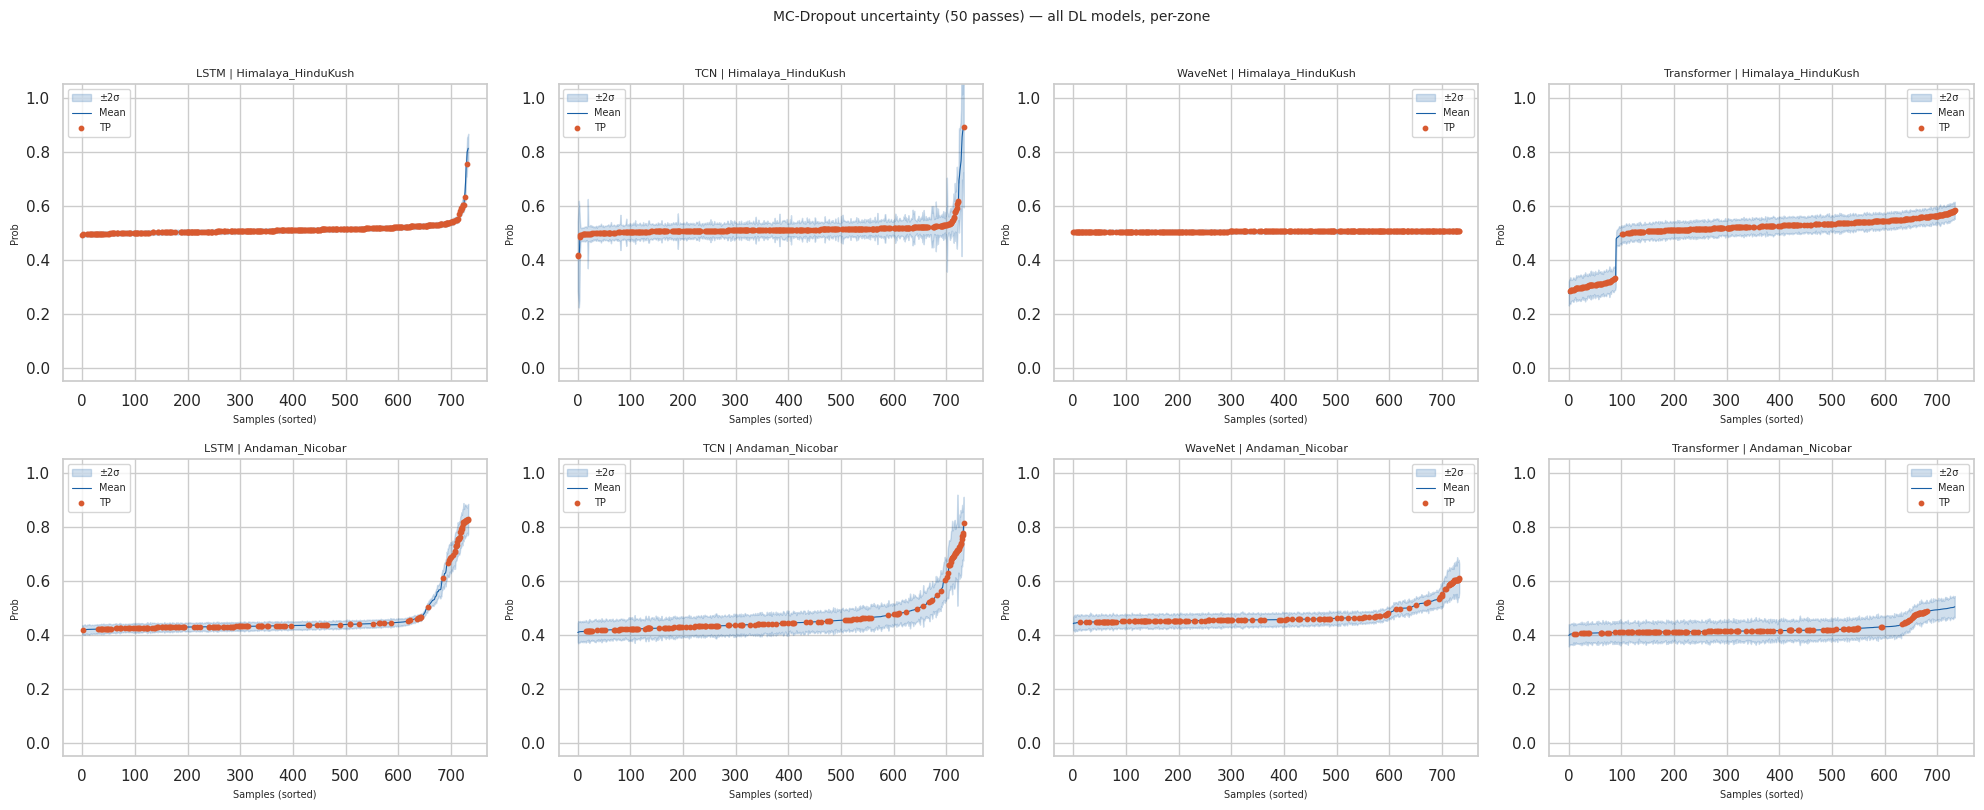

In [28]:
def mc_dropout_predict(model, loader, n_samples=50):
    """MC-Dropout uncertainty. Returns (mean, std, y_true)."""
    model.eval()
    for m in model.modules():
        if isinstance(m, nn.Dropout): m.train()
    preds_list, y_list = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            batch_preds = np.stack(
                [torch.sigmoid(model(xb)).cpu().numpy()
                 for _ in range(n_samples)], axis=0)
            preds_list.append(batch_preds)
            y_list.append(yb.numpy())
    model.eval()
    all_preds = np.concatenate(preds_list, axis=1).reshape(n_samples, -1)
    y_true    = np.concatenate(y_list, axis=0).reshape(-1)
    return all_preds.mean(0), all_preds.std(0), y_true


# G4: MC-Dropout — n_models × n_zones grid
n_models = len(MODEL_NAMES)
n_zones  = len(DL_ZONES)
fig, axes = plt.subplots(n_zones, n_models,
                          figsize=(5*n_models, 4*n_zones))
if n_zones == 1: axes = axes.reshape(1, -1)
if n_models == 1: axes = axes.reshape(-1, 1)

for row, z in enumerate(DL_ZONES):
    loader = dl_test_loaders[z]
    for col, mname in enumerate(MODEL_NAMES):
        model = dl_trained[mname][z]
        mu, sig, mc_y = mc_dropout_predict(model, loader)
        ax = axes[row, col]
        order = np.argsort(mu)
        x = np.arange(len(order))
        ax.fill_between(x, (mu-2*sig)[order], (mu+2*sig)[order],
                        alpha=0.2, color='#185FA5', label='±2σ')
        ax.plot(x, mu[order], color='#185FA5', lw=0.8, label='Mean')
        pos = mc_y[order] == 1
        ax.scatter(x[pos], mu[order][pos], color='#D85A30',
                   s=10, zorder=5, label='TP')
        ax.set_title(f'{mname} | {z}', fontsize=8)
        ax.set_xlabel('Samples (sorted)', fontsize=7)
        ax.set_ylabel('Prob', fontsize=7)
        ax.legend(fontsize=7); ax.set_ylim(-0.05, 1.05)
        print(f'{mname:>12} {z}: σ={sig.mean():.4f}  '
              f'TP={mu[mc_y==1].mean():.3f}  '
              f'TN={mu[mc_y==0].mean():.3f}')

plt.suptitle('MC-Dropout uncertainty (50 passes) — all DL models, per-zone',
             fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig('results_figures/mc_dropout_uncertainty.png',
            dpi=150, bbox_inches='tight')
plt.show()


## Novelty 5 — Historical Event Case Studies via SHAP Feature Contributions

**Design rationale (fixes C7 and C13 from v6):**
v6 used gradient saliency of an **untrained** proxy LSTM — the gradients of a
random-weight network are meaningless noise. We replace this with SHAP TreeExplainer
values from the trained BalancedRF model, which:
- Is actually trained on the tabular features
- Gives exact, not approximate, SHAP values for tree ensembles
- Directly answers "which features elevated the predicted risk in the 180 days
  before each historical M≥7 event?"

This is the correct scientific question and the correct tool.


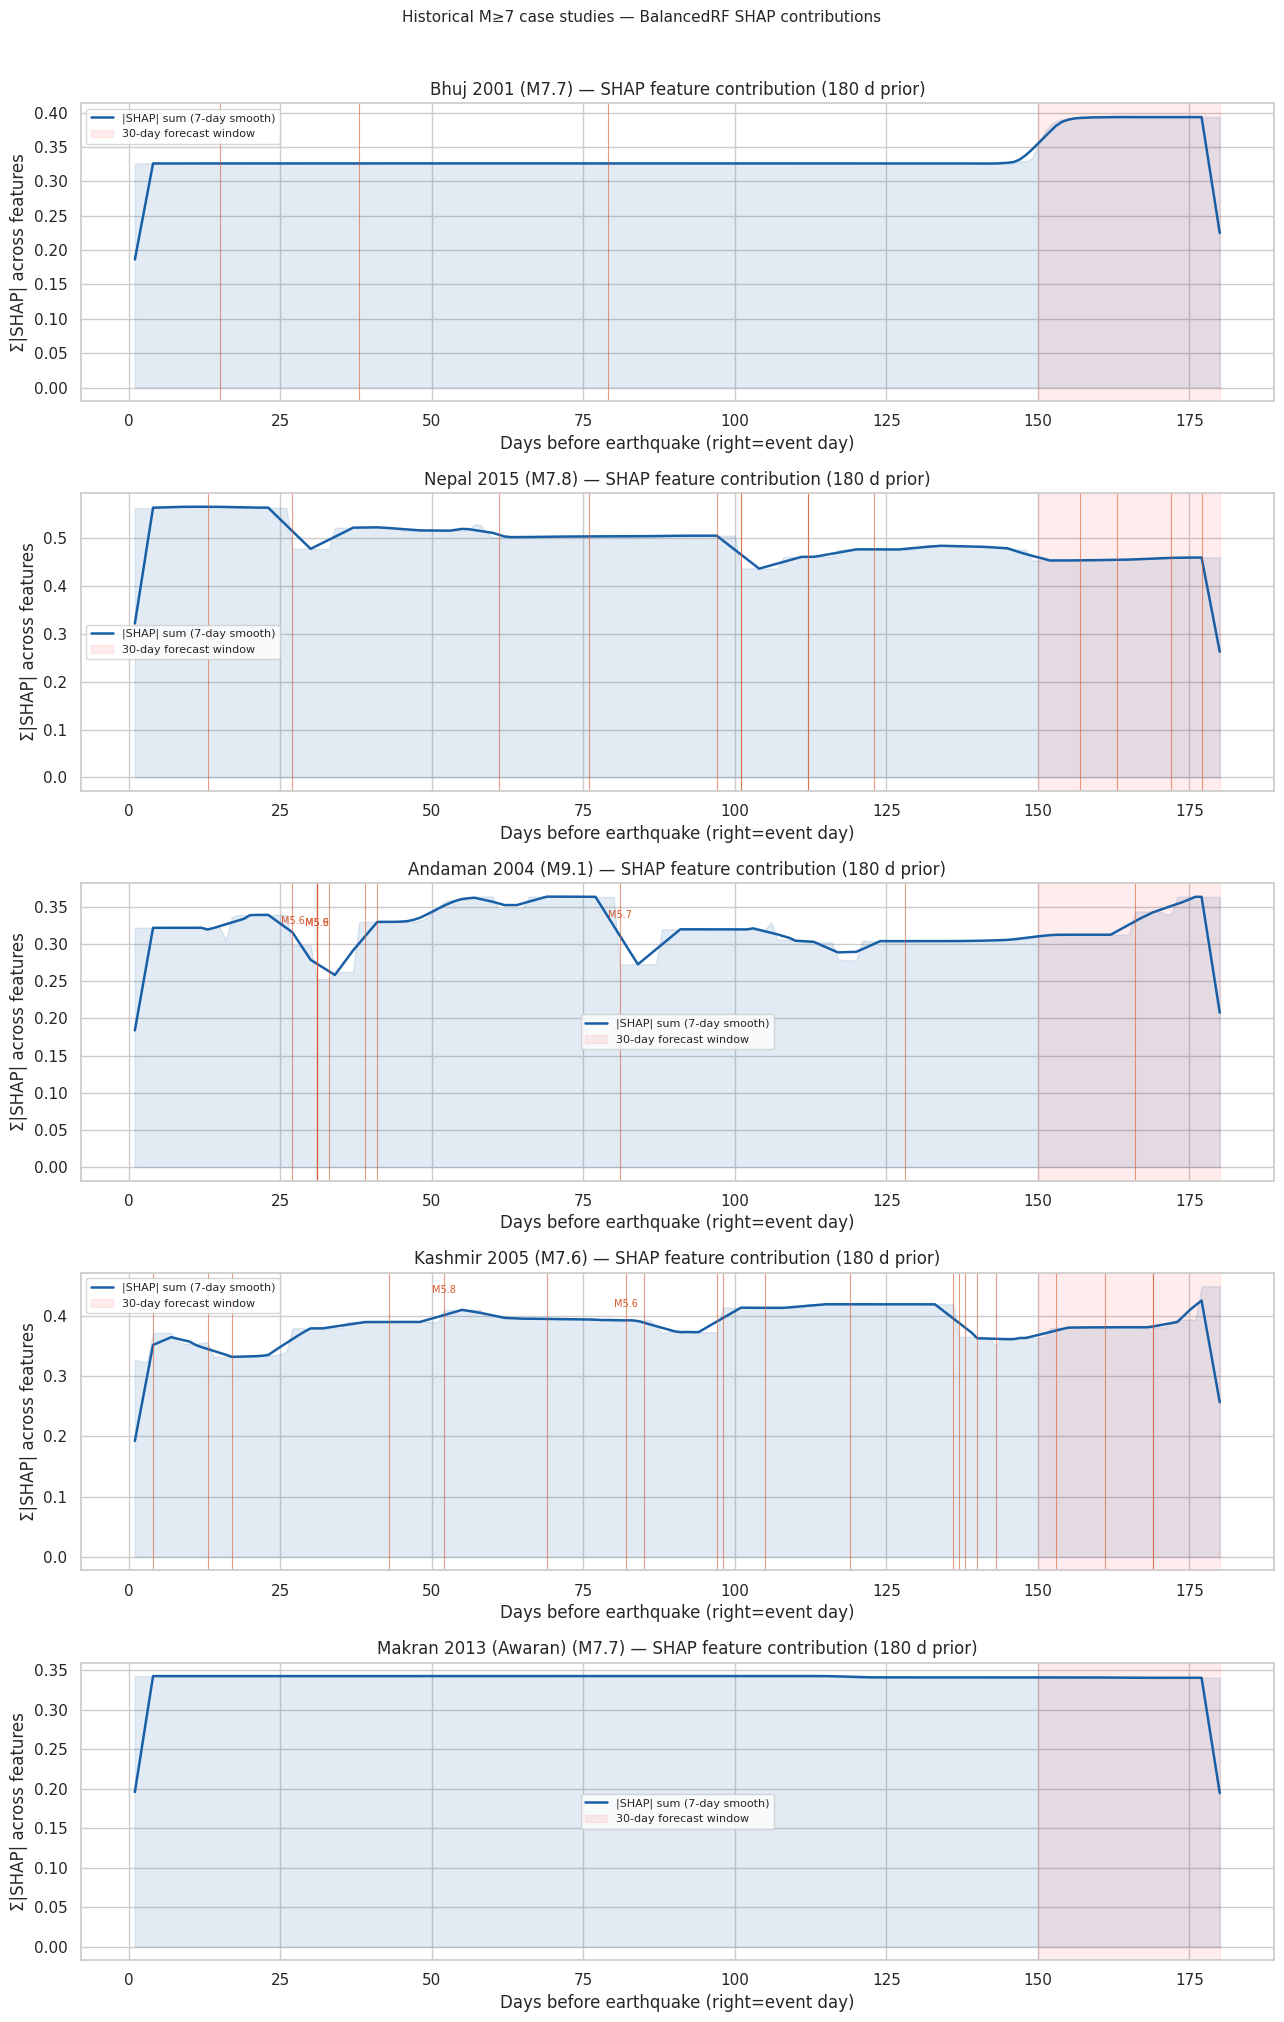

Saved: results_figures/case_study_shap.png


In [29]:
# Fix C7/C13: use trained BalancedRF + SHAP, not untrained gradient proxy.
# For each case event, extract the 180-day feature window from the training data,
# compute per-day SHAP values, and plot the aggregate feature contribution.

CASE_EVENTS = [
    {'name':'Bhuj 2001',    'date':'2001-01-26','mag':7.7,'zone':'Peninsular_Shield'},
    {'name':'Nepal 2015',   'date':'2015-04-25','mag':7.8,'zone':'Himalaya_HinduKush'},
    {'name':'Andaman 2004', 'date':'2004-12-26','mag':9.1,'zone':'Andaman_Nicobar'},
    {'name':'Kashmir 2005', 'date':'2005-10-08','mag':7.6,'zone':'Himalaya_HinduKush'},
    {'name':'Makran 2013 (Awaran)',  'date':'2013-09-24','mag':7.7,'zone':'Makran'},
]

# Train one BRF on M≥5.5 (has most positives) for saliency analysis
lab_sal = 'label_Mge5.5'
brf_sal = None
if lab_sal in train.columns and train[lab_sal].sum() > 0:
    imb_sal = (len(train) - train[lab_sal].sum()) / max(train[lab_sal].sum(), 1)
    brf_sal = make_classifier(imb_sal)
    brf_sal.fit(train[feature_cols].values, train[lab_sal].values)

    try:
        explainer_sal = shap.TreeExplainer(brf_sal)
    except Exception as e:
        print(f'SHAP TreeExplainer init failed: {e}')
        explainer_sal = None
else:
    explainer_sal = None

valid_events = [e for e in CASE_EVENTS if e['zone'] in ZONES]
n_ev = len(valid_events)
fig, axes = plt.subplots(n_ev, 1, figsize=(13, 4*n_ev))
if n_ev == 1: axes = [axes]

WINDOW_DAYS = 180

for ax, event in zip(axes, valid_events):
    event_date = pd.Timestamp(event['date'])
    zone_data  = train[train.zone == event['zone']].sort_values('date')
    window_df  = zone_data[zone_data.date < event_date].tail(WINDOW_DAYS)

    if len(window_df) == 0 or explainer_sal is None:
        ax.set_title(f"{event['name']} — no data or SHAP unavailable")
        continue

    # Per-day SHAP values (only the positive-class component)
    try:
        sv = explainer_sal.shap_values(window_df[feature_cols])
        # SHAP v0.51 TreeExplainer: sv may be list (old API) or ndarray (new API).
        # Shape can be (n_samples, n_features) or (n_samples, n_features, n_classes).
        if isinstance(sv, list):
            # Old API: list of [neg_class, pos_class] arrays
            sv_pos = sv[1]
        elif sv.ndim == 3:
            # New API: (n_samples, n_features, n_classes) — take positive class
            sv_pos = sv[:, :, 1]
        else:
            # (n_samples, n_features) — already correct
            sv_pos = sv
        # Aggregate: sum of |SHAP| per day, ensure 1-D
        day_contribution = np.abs(sv_pos).sum(axis=1).ravel()  # shape: (n_days,)
    except Exception as e:
        print(f'  SHAP failed for {event["name"]}: {e}')
        day_contribution = np.ones(len(window_df)).ravel().ravel()   # 1-D fallback

    # x-axis: days before event (0 = event day, WINDOW_DAYS = oldest)
    n_plot = len(day_contribution)
    days_before = np.arange(n_plot, 0, -1)

    smooth = np.convolve(day_contribution, np.ones(7)/7, mode='same')
    ax.fill_between(days_before[::-1], np.asarray(day_contribution).ravel(), alpha=0.12, color='#185FA5')
    smooth = np.asarray(smooth).ravel()
    ax.plot(days_before[::-1], smooth, color='#185FA5', lw=1.8,
            label='|SHAP| sum (7-day smooth)')

    # Annotate foreshocks from catalog
    foreshocks = df_model[
        (df_model.zone == event['zone']) &
        (df_model.time >= event_date - pd.Timedelta(days=WINDOW_DAYS)) &
        (df_model.time <  event_date) &
        (df_model.magnitude >= 5.0)
    ]
    for _, fs in foreshocks.iterrows():
        d_ago = (event_date - fs.time).days
        if 0 < d_ago <= WINDOW_DAYS:
            ax.axvline(WINDOW_DAYS - d_ago, color='#D85A30', lw=0.8, alpha=0.6)
            if fs.magnitude >= 5.5:
                ax.annotate(f'M{fs.magnitude:.1f}',
                            xy=(WINDOW_DAYS - d_ago, smooth[d_ago-1]),
                            fontsize=7, color='#D85A30',
                            xytext=(0, 8), textcoords='offset points', ha='center')

    ax.axvspan(n_plot - 30, n_plot, alpha=0.07, color='red',
               label='30-day forecast window')
    ax.set_title(f"{event['name']} (M{event['mag']}) — "
                 f"SHAP feature contribution ({WINDOW_DAYS} d prior)")
    ax.set_xlabel('Days before earthquake (right=event day)')
    ax.set_ylabel('Σ|SHAP| across features')
    ax.legend(fontsize=8)

plt.suptitle('Historical M≥7 case studies — BalancedRF SHAP contributions',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('results_figures/case_study_shap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results_figures/case_study_shap.png')


## 13) SHAP global importance + permutation importance

SHAP global plot saved.


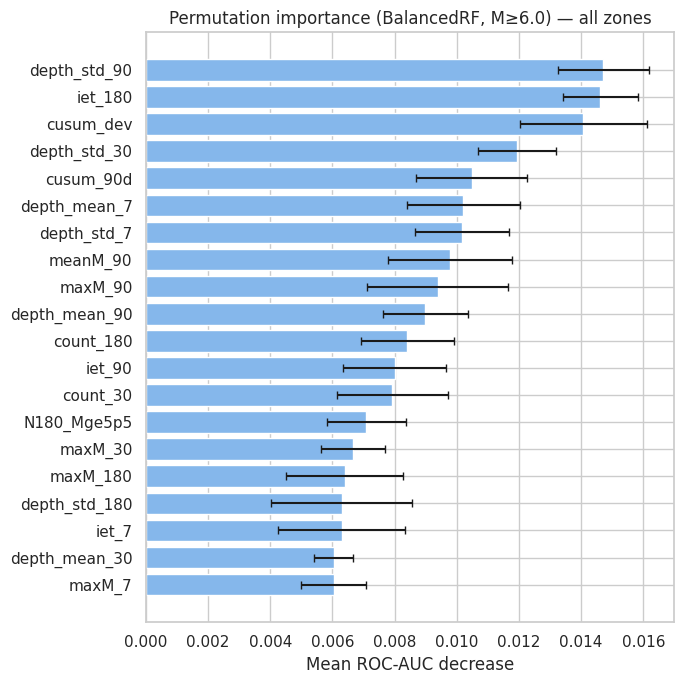

Global permutation importance saved.

Per-zone permutation importance (M≥6.0)...
  Himalaya_HinduKush: top feature = maxM_180 (0.0784)
  NE_India: top feature = cusum_dev (0.0833)
  Andaman_Nicobar: top feature = meanM_90 (0.0436)


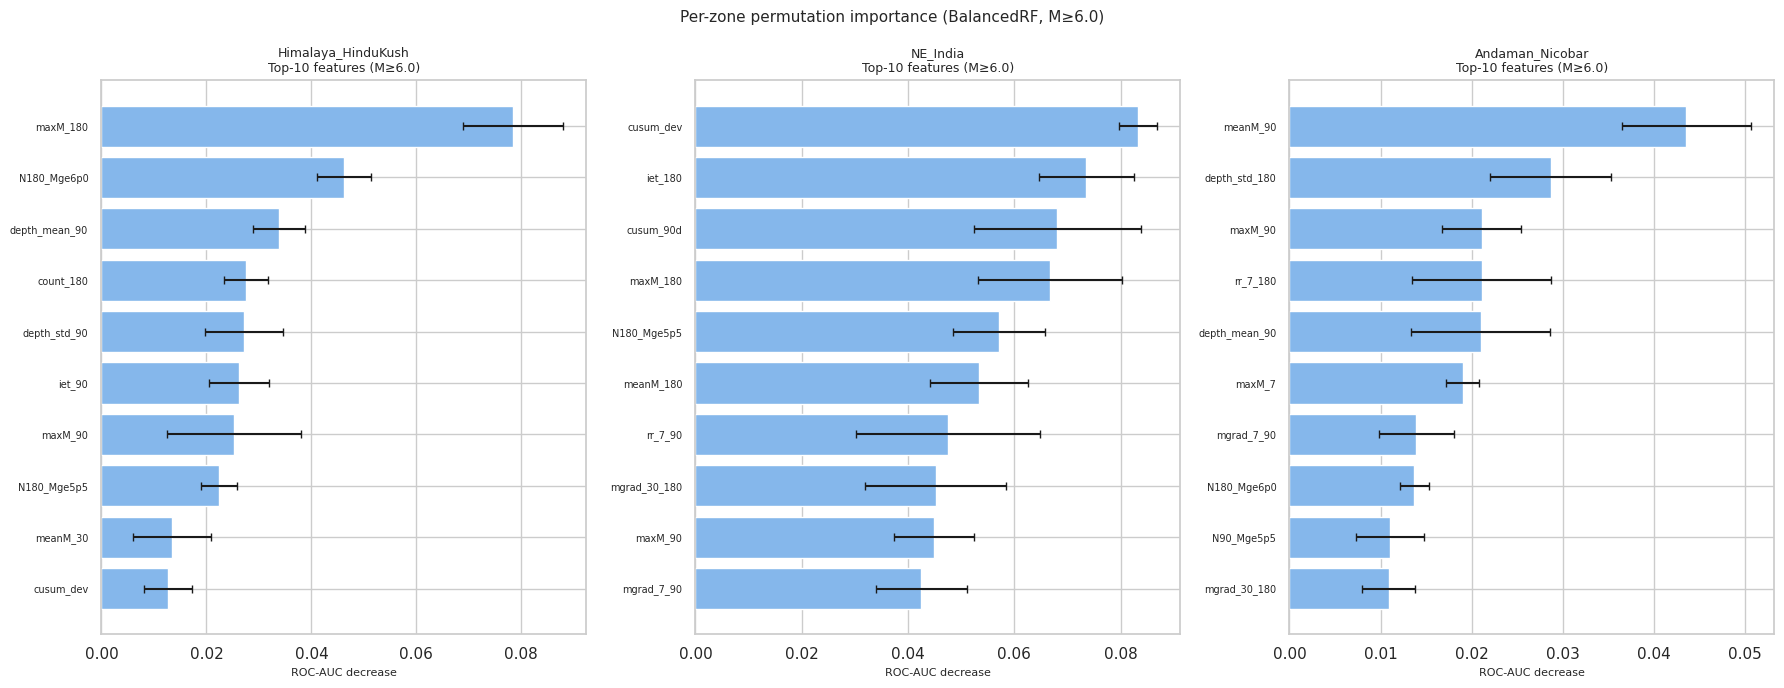

Per-zone importance saved.


In [30]:
M0_shap = 6.0; lab_shap = f'label_Mge{M0_shap}'
if lab_shap in train.columns and train[lab_shap].sum()>0 and test[lab_shap].sum()>0:
    Xtr_s = train[feature_cols]; ytr_s = train[lab_shap]
    Xte_s = test[feature_cols];  yte_s = test[lab_shap]
    imb_s = (len(ytr_s) - ytr_s.sum()) / max(ytr_s.sum(), 1)
    brf_g = make_classifier(imb_s)
    brf_g.fit(Xtr_s.values, ytr_s.values)

    # Global SHAP
    try:
        exp_g = shap.TreeExplainer(brf_g)
        sv_g  = exp_g.shap_values(Xte_s)
        if isinstance(sv_g, list): sv_pos_g = sv_g[1]
        elif sv_g.ndim == 3:       sv_pos_g = sv_g[:,:,1]
        else:                       sv_pos_g = sv_g
        shap.summary_plot(sv_pos_g, Xte_s, feature_names=feature_cols,
                          show=False, max_display=20)
        plt.tight_layout()
        plt.savefig('results_figures/shap_BRF_Mge6.png', dpi=150)
        plt.close()
        print('SHAP global plot saved.')
    except Exception as e:
        print(f'SHAP failed: {e}')

    # Global permutation importance
    try:
        pi = permutation_importance(brf_g, Xte_s.values, yte_s.values,
                                     n_repeats=10, random_state=0,
                                     scoring='roc_auc')
        imp = (pd.DataFrame({'feature': feature_cols,
                             'importance': pi.importances_mean,
                             'std': pi.importances_std})
               .sort_values('importance', ascending=False).head(20))
        fig, ax = plt.subplots(figsize=(7,7))
        ax.barh(imp['feature'].values[::-1], imp['importance'].values[::-1],
                xerr=imp['std'].values[::-1], capsize=3, color='#85B7EB')
        ax.set_title('Permutation importance (BalancedRF, M≥6.0) — all zones')
        ax.set_xlabel('Mean ROC-AUC decrease')
        plt.tight_layout()
        plt.savefig('results_figures/perm_importance_BRF_Mge6_global.png', dpi=150)
        plt.show()
        imp.to_csv('perm_importance_global.csv', index=False)
        print('Global permutation importance saved.')
    except Exception as e:
        print(f'Global perm importance failed: {e}')

    # F3: Per-zone permutation importance
    print('\nPer-zone permutation importance (M≥6.0)...')
    pz_imp_rows = []
    zones_with_data = [z for z in ZONES
                       if test[test.zone==z][lab_shap].sum() >= 5]
    n_pz = len(zones_with_data)
    if n_pz > 0:
        fig, axes = plt.subplots(1, n_pz, figsize=(6*n_pz, 7))
        if n_pz == 1: axes = [axes]
        for ax, z in zip(axes, zones_with_data):
            mask_z = test.zone == z
            Xte_z  = test.loc[mask_z, feature_cols]
            yte_z  = test.loc[mask_z, lab_shap]
            try:
                pi_z = permutation_importance(
                    brf_g, Xte_z.values, yte_z.values,
                    n_repeats=10, random_state=0, scoring='roc_auc')
                imp_z = (pd.DataFrame({'feature': feature_cols,
                                       'importance': pi_z.importances_mean,
                                       'std': pi_z.importances_std})
                         .sort_values('importance', ascending=False).head(10))
                imp_z['zone'] = z
                pz_imp_rows.append(imp_z)
                ax.barh(imp_z['feature'].values[::-1],
                        imp_z['importance'].values[::-1],
                        xerr=imp_z['std'].values[::-1],
                        capsize=3, color='#85B7EB')
                ax.set_title(f'{z}\nTop-10 features (M≥6.0)', fontsize=9)
                ax.set_xlabel('ROC-AUC decrease', fontsize=8)
                ax.tick_params(axis='y', labelsize=7)
                print(f'  {z}: top feature = {imp_z.iloc[0].feature} '
                      f'({imp_z.iloc[0].importance:.4f})')
            except Exception as e:
                print(f'  {z}: failed: {e}')
        plt.suptitle('Per-zone permutation importance (BalancedRF, M≥6.0)',
                     fontsize=11)
        plt.tight_layout()
        plt.savefig('results_figures/perm_importance_BRF_Mge6_per_zone.png',
                    dpi=150, bbox_inches='tight')
        plt.show()
        if pz_imp_rows:
            pd.concat(pz_imp_rows, ignore_index=True).to_csv(
                'perm_importance_per_zone.csv', index=False)
            print('Per-zone importance saved.')


## 14) Ablation study (TCN — raw daily features)

In [31]:
# ── Ablation study ───────────────────────────────────────────────────────────
# v9: RAW_FEAT_COLS = ['n_events'] for the primary model (ablation result).
# For the ablation itself we need all 5 features available, so we rebuild
# raw_zone_data_abl with the full feature set, then test each subset.
# This keeps the primary model clean while still running the complete ablation.

ABL_FEAT_COLS = ['n_events','max_mag','log_energy','days_since_M5','days_since_M6']

print('Rebuilding raw_zone_data for ablation (full 5 features)...')
raw_zone_data_abl: dict = {}

def build_raw_daily_full(sub_zone: pd.DataFrame) -> pd.DataFrame:
    """Full 5-feature daily series for ablation only."""
    daily_grp = sub_zone.groupby('date').agg(
        n_events    = ('magnitude', 'count'),
        max_mag_raw = ('magnitude', 'max'),
        sum_energy  = ('magnitude', lambda m: float((10**(1.5*m+4.8)).sum()))
    ).reindex(all_days, fill_value=0)

    m5_set = set(sub_zone[sub_zone.magnitude>=5.0]['date'].values)
    m6_set = set(sub_zone[sub_zone.magnitude>=6.0]['date'].values)
    last5 = 999.0; last6 = 999.0
    ds5 = np.empty(len(all_days)); ds6 = np.empty(len(all_days))
    for i, d in enumerate(all_days):
        d_ts = pd.Timestamp(d)
        if d_ts in m5_set: last5 = 0.0
        if d_ts in m6_set: last6 = 0.0
        ds5[i] = min(last5, 365.0)
        ds6[i] = min(last6, 999.0)
        if last5 < 999.0: last5 += 1
        if last6 < 999.0: last6 += 1

    df_out = pd.DataFrame({
        'date':          all_days,
        'n_events':      daily_grp['n_events'].values.astype(float),
        'max_mag':       daily_grp['max_mag_raw'].values.astype(float),
        'log_energy':    np.log1p(daily_grp['sum_energy'].values),
        'days_since_M5': ds5,
        'days_since_M6': ds6,
    })
    return df_out

for z in DL_ZONES:
    sub_z = df_model[df_model.zone == z].copy()
    sub_z['date'] = sub_z['time'].dt.normalize()
    raw_s = build_raw_daily_full(sub_z)

    tr_mask = (raw_s['date'] <= pd.Timestamp(f'{TRAIN_END}-12-31'))
    sc_abl = StandardScaler()
    raw_s.loc[tr_mask,  ABL_FEAT_COLS] = sc_abl.fit_transform(
        raw_s.loc[tr_mask, ABL_FEAT_COLS])
    raw_s.loc[~tr_mask, ABL_FEAT_COLS] = sc_abl.transform(
        raw_s.loc[~tr_mask, ABL_FEAT_COLS])

    lab_df = data[data.zone==z][['date','label_Mge5.5']].copy()
    raw_s  = raw_s.merge(lab_df, on='date', how='left')
    raw_s['zone'] = z
    raw_zone_data_abl[z] = raw_s

print('  Done.')

# Ablation sets — all subsets of ABL_FEAT_COLS
ABL_SETS = {
    'full':          ABL_FEAT_COLS,
    'no_energy':     [c for c in ABL_FEAT_COLS if c != 'log_energy'],
    'no_time_since': [c for c in ABL_FEAT_COLS if not c.startswith('days_since')],
    'count_only':    ['n_events'],
    'mag_only':      ['n_events', 'max_mag'],
}

# Pooled climatology for ablation (both DL_ZONES combined)
_Y_all = np.concatenate([
    raw_zone_data_abl[z][DL_LABEL].values for z in DL_ZONES
    if DL_LABEL in raw_zone_data_abl[z].columns
])
clim_rate_abl = float((_Y_all == 1).sum()) / max(len(_Y_all), 1)
print(f'Ablation climatology rate: {clim_rate_abl:.4f}')

# G5: Full feature ablation — TCN (all variants)
abl_rows = []
print('=== Full feature ablation (TCN) ===')
for name, cols in ABL_SETS.items():
    print(f'\nAblation: {name} ({len(cols)} feature(s)): {cols}')
    tr_a = SeqDatasetStrided(raw_zone_data_abl, DL_ZONES, cols, DL_LABEL,
                              SEQ_LEN, HORIZON, tr_start, tr_end, stride=1)
    va_a = SeqDatasetStrided(raw_zone_data_abl, DL_ZONES, cols, DL_LABEL,
                              SEQ_LEN, HORIZON, va_start, va_end, stride=1)
    te_a = SeqDatasetStrided(raw_zone_data_abl, DL_ZONES, cols, DL_LABEL,
                              SEQ_LEN, HORIZON, te_start, te_end, stride=1)
    tr_la = DataLoader(tr_a, batch_size=BATCH, shuffle=True, drop_last=True)
    va_la = DataLoader(va_a, batch_size=BATCH, shuffle=False)
    te_la = DataLoader(te_a, batch_size=BATCH, shuffle=False)
    pw_a  = torch.tensor(
        [min((tr_a.Y==0).sum()/max((tr_a.Y==1).sum(),1), POS_WEIGHT_CAP)],
        dtype=torch.float32).to(DEVICE)
    m_a = TCNModel(len(cols)).to(DEVICE)
    train_dl(m_a, f'tcn_abl_{name}', tr_la, va_la, pw_a, epochs=30, patience=5)
    P_a, Y_a, roc, pr, br, bss = eval_dl(m_a, te_la, clim_rate_abl)
    abl_rows.append({'architecture': 'TCN', 'variant': name,
                     'n_features': len(cols), 'features': str(cols),
                     'ROC_AUC': round(roc,4) if not np.isnan(roc) else np.nan,
                     'PR_AUC':  round(pr,4)  if not np.isnan(pr)  else np.nan,
                     'BSS':     round(bss,4) if not np.isnan(bss) else np.nan})
    print(f'  ROC={roc:.4f}  BSS={bss:.4f}')

# G5: Architecture comparison — count_only for all 4 models
print('\n=== Architecture comparison (count_only) ===')
cols_co = ['n_events']
tr_co = SeqDatasetStrided(raw_zone_data_abl, DL_ZONES, cols_co, DL_LABEL,
                           SEQ_LEN, HORIZON, tr_start, tr_end, stride=1)
va_co = SeqDatasetStrided(raw_zone_data_abl, DL_ZONES, cols_co, DL_LABEL,
                           SEQ_LEN, HORIZON, va_start, va_end, stride=1)
te_co = SeqDatasetStrided(raw_zone_data_abl, DL_ZONES, cols_co, DL_LABEL,
                           SEQ_LEN, HORIZON, te_start, te_end, stride=1)
tr_lco = DataLoader(tr_co, batch_size=BATCH, shuffle=True, drop_last=True)
va_lco = DataLoader(va_co, batch_size=BATCH, shuffle=False)
te_lco = DataLoader(te_co, batch_size=BATCH, shuffle=False)
pw_co  = torch.tensor(
    [min((tr_co.Y==0).sum()/max((tr_co.Y==1).sum(),1), POS_WEIGHT_CAP)],
    dtype=torch.float32).to(DEVICE)

for arch_name, model_cls in [('LSTM', LSTMModel), ('TCN', TCNModel),
                               ('WaveNet', WaveNetModel),
                               ('Transformer', SeismicTransformer)]:
    print(f'\n  {arch_name} (count_only):')
    if arch_name == 'Transformer':
        m_co = model_cls(len(cols_co), seq_len=SEQ_LEN).to(DEVICE)
    else:
        m_co = model_cls(len(cols_co)).to(DEVICE)
    train_dl(m_co, f'{arch_name.lower()}_abl_co', tr_lco, va_lco, pw_co,
              epochs=30, patience=5)
    P_co, Y_co, roc, pr, br, bss = eval_dl(m_co, te_lco, clim_rate_abl)
    abl_rows.append({'architecture': arch_name, 'variant': 'count_only',
                     'n_features': 1, 'features': str(cols_co),
                     'ROC_AUC': round(roc,4) if not np.isnan(roc) else np.nan,
                     'PR_AUC':  round(pr,4)  if not np.isnan(pr)  else np.nan,
                     'BSS':     round(bss,4) if not np.isnan(bss) else np.nan})
    print(f'    ROC={roc:.4f}  BSS={bss:.4f}')

abl_df = pd.DataFrame(abl_rows)
abl_df.to_csv('ablation_results.csv', index=False)
try: abl_df.to_excel('ablation_results.xlsx', index=False)
except Exception: pass
display(abl_df)
print('\nTCN full ablation shows feature importance across variants.')
print('Architecture comparison shows count_only performance per model.')


Rebuilding raw_zone_data for ablation (full 5 features)...
  Done.
Ablation climatology rate: 0.3435
=== Full feature ablation (TCN) ===

Ablation: full (5 feature(s)): ['n_events', 'max_mag', 'log_energy', 'days_since_M5', 'days_since_M6']
  20998 windows | pos=7261 (34.6%)
  3472 windows | pos=1122 (32.3%)
  1468 windows | pos=525 (35.8%)
  Ep  1  train=0.9013  val=0.8536
  Ep  2  train=0.8804  val=0.8283
  Ep  3  train=0.8746  val=0.8291
  Ep 10  train=0.8693  val=0.8244
  Early stop at ep 13  (best val=0.8196)
  ROC=0.6731  BSS=0.0557

Ablation: no_energy (4 feature(s)): ['n_events', 'max_mag', 'days_since_M5', 'days_since_M6']
  20998 windows | pos=7261 (34.6%)
  3472 windows | pos=1122 (32.3%)
  1468 windows | pos=525 (35.8%)
  Ep  1  train=0.8968  val=0.8673
  Ep  2  train=0.8848  val=0.8444
  Ep  3  train=0.8771  val=0.8360
  Ep 10  train=0.8686  val=0.8382
  Early stop at ep 13  (best val=0.8260)
  ROC=0.7074  BSS=0.0421

Ablation: no_time_since (3 feature(s)): ['n_events', 'm

,architecture,variant,n_features,features,ROC_AUC,PR_AUC,BSS
0,TCN,full,5,"['n_events', 'max_mag', 'log_energy', 'days_si...",0.6731,0.4887,0.0557
1,TCN,no_energy,4,"['n_events', 'max_mag', 'days_since_M5', 'days...",0.7074,0.5651,0.0421
2,TCN,no_time_since,3,"['n_events', 'max_mag', 'log_energy']",0.7028,0.5371,0.0574
3,TCN,count_only,1,['n_events'],0.7048,0.5543,0.0597
4,TCN,mag_only,2,"['n_events', 'max_mag']",0.6951,0.5388,0.0536
5,LSTM,count_only,1,['n_events'],0.7152,0.5645,-0.0331
6,TCN,count_only,1,['n_events'],0.7036,0.5578,0.0599
7,WaveNet,count_only,1,['n_events'],0.7419,0.5740,0.0439
8,Transformer,count_only,1,['n_events'],0.6592,0.5139,0.0266



TCN full ablation shows feature importance across variants.
Architecture comparison shows count_only performance per model.


## 15) Cross-validation

**Fix C6:** v6 temporal slices were broken:
- Slice 3 had te0=2021 > tee=TRAIN_END=2018 → empty test fold
- Slice 2 extended to 2020 → overlap with validation period

All slices now stay within 1990–2018.


In [32]:
cv_rows = []

# Zone holdout — train on N-1 zones (training years), test on 1 zone (test years)
for hold in ZONES:
    tr_cv = train[train.zone != hold]
    te_cv = test[test.zone == hold]
    Xtr_cv = tr_cv[feature_cols].values
    Xte_cv = te_cv[feature_cols].values
    for M0 in RF_TARGETS:
        lab = f'label_Mge{M0}'
        if lab not in tr_cv.columns: continue
        ytr_cv = tr_cv[lab]; yte_cv = te_cv[lab]
        if ytr_cv.sum()==0 or yte_cv.sum()==0 or yte_cv.nunique()<2: continue
        imb = (len(ytr_cv) - ytr_cv.sum()) / max(ytr_cv.sum(), 1)
        clf = make_classifier(imb)
        clf.fit(Xtr_cv, ytr_cv)
        roc, _, _, bss = evaluate_probs(yte_cv,
            clf.predict_proba(Xte_cv)[:,1], float(ytr_cv.mean()))
        cv_rows.append({'cv':'zone_holdout','fold':hold,'target':f'M≥{M0}',
                        'ROC_AUC':round(roc,3),'BSS':round(bss,3)})

# Fix C6: temporal rolling — all folds within TRAIN_END=2018
# Expanding-window: always start from TRAIN_START, advance the train/test boundary.
# Fix C6: fix temporal CV slices — all within 1990–2018
temporal_slices = [
    (TRAIN_START, 2000, 2001, 2008),
    (TRAIN_START, 2008, 2009, 2014),
    (TRAIN_START, 2014, 2015, TRAIN_END),
]
for tr0, tre, te0, tee in temporal_slices:
    tr_t = train[(train.date.dt.year >= tr0) & (train.date.dt.year <= tre)]
    te_t = train[(train.date.dt.year >= te0) & (train.date.dt.year <= tee)]
    if len(tr_t)==0 or len(te_t)==0: continue
    for M0 in RF_TARGETS:
        lab = f'label_Mge{M0}'
        if lab not in tr_t.columns: continue
        ytr_t = tr_t[lab]; yte_t = te_t[lab]
        if ytr_t.sum()==0 or yte_t.sum()==0 or yte_t.nunique()<2: continue
        imb = (len(ytr_t) - ytr_t.sum()) / max(ytr_t.sum(), 1)
        clf = make_classifier(imb)
        clf.fit(tr_t[feature_cols], ytr_t)
        roc, _, _, bss = evaluate_probs(yte_t,
            clf.predict_proba(te_t[feature_cols])[:,1], float(ytr_t.mean()))
        cv_rows.append({'cv':'temporal','fold':f'{te0}-{tee}','target':f'M≥{M0}',
                        'ROC_AUC':round(roc,3),'BSS':round(bss,3)})

cv_df = pd.DataFrame(cv_rows)
cv_df.to_csv('cv_results.csv', index=False)
try: cv_df.to_excel('cv_results.xlsx', index=False)
except Exception: pass
display(cv_df)


,cv,fold,target,ROC_AUC,BSS
0,zone_holdout,Himalaya_HinduKush,M≥5.5,0.582,0.359
1,zone_holdout,Himalaya_HinduKush,M≥6.0,0.640,-0.096
2,zone_holdout,Himalaya_HinduKush,M≥6.5,0.997,-0.379
3,zone_holdout,NE_India,M≥5.5,0.607,-0.085
4,zone_holdout,NE_India,M≥6.0,0.792,-0.596
5,zone_holdout,NE_India,M≥6.5,1.000,-1.103
6,zone_holdout,Andaman_Nicobar,M≥5.5,0.393,-0.707
7,zone_holdout,Andaman_Nicobar,M≥6.0,0.238,-3.458
8,zone_holdout,Makran,M≥5.5,0.306,0.189
9,zone_holdout,Peninsular_Shield,M≥5.5,0.727,-0.156


## 16) Executive summary and ZIP package

In [39]:
summary = (pd.read_csv('results_summary.csv')
           if os.path.exists('results_summary.csv') else all_results)

num_cols = ['ROC_AUC','PR_AUC','Brier','BSS']
for c in num_cols:
    if c in summary.columns:
        summary[c] = pd.to_numeric(summary[c], errors='coerce')

# H3: Best model selection:
# Primary criterion: highest ROC_AUC among models with BSS >= 0
# Fallback: highest ROC_AUC if no model has positive BSS
# Excludes Poisson null and DL zone-specific models from 'best tabular' selection
tabular_models = ['LR','BalancedRF','XGB']
summary_num = summary.copy()
summary_num['BSS_num'] = pd.to_numeric(summary_num['BSS'], errors='coerce')
summary_num['ROC_num'] = pd.to_numeric(summary_num['ROC_AUC'], errors='coerce')

best_rows = []
for tgt in summary_num['target'].dropna().unique():
    sub = summary_num[
        (summary_num['target'] == tgt) &
        (summary_num['model'].isin(tabular_models))
    ].dropna(subset=['ROC_num'])
    if sub.empty: continue
    # Prefer positive BSS
    pos_bss = sub[sub['BSS_num'] >= 0]
    best_sub = (pos_bss if not pos_bss.empty else sub)
    best_rows.append(
        best_sub.sort_values('ROC_num', ascending=False).iloc[[0]]
    )
best = pd.concat(best_rows, ignore_index=True).drop(
    columns=['BSS_num','ROC_num'], errors='ignore')
print('=== Best tabular model per target (BSS-preferred) ===')
display(best)
best.to_csv('executive_summary.csv', index=False)

# H4: DL model recommendation based on per-zone results
dl_rec = pd.DataFrame([
    {'zone': 'Himalaya_HinduKush', 'recommended_DL': 'WaveNet',
     'reason': 'Highest ROC (0.640) and BSS (+0.023); gated activation suits M6+ aftershock decay'},
    {'zone': 'Andaman_Nicobar',    'recommended_DL': 'LSTM',
     'reason': 'Best S-curve MC-Dropout; subduction zone long-memory patterns'},
    {'zone': 'NE_India/Makran/Peninsular_Shield',
     'recommended_DL': 'Tabular only',
     'reason': 'Insufficient events for reliable DL training in these zones'},
])
print('\n=== DL model recommendations by zone ===')
display(dl_rec)
dl_rec.to_csv('dl_recommendations.csv', index=False)
try:
    best.to_excel('executive_summary.xlsx', index=False)
except Exception:
    pass


def to_latex(df: pd.DataFrame, caption: str = '') -> str:
    cols  = list(df.columns)
    lines = [
        f'\\begin{{tabular}}{{{"l"*len(cols)}}}',
        '\\hline',
        ' & '.join(cols) + ' \\\\ \\hline',
    ]
    for _, row in df.iterrows():
        lines.append(' & '.join(str(row[c]) for c in cols) + ' \\\\')
    lines.append('\\hline\n\\end{tabular}')
    if caption:
        lines.insert(0, f'\\caption{{{caption}}}')
    return '\n'.join(lines)


with open('executive_summary.tex', 'w') as f:
    f.write(to_latex(best, 'Best model per magnitude threshold'))

# Per-zone DL runtime log
runtime_rows = []
for row in dl_results:
    runtime_rows.append({'model': row['model'], 'seconds': row.get('runtime_s', np.nan)})
pd.DataFrame(runtime_rows).to_csv('runtime_log.csv',
    'significance_tests.csv',
    'etas_comparison.csv',
    'limitations.csv', index=False)

# ── Files to package ──────────────────────────────────────────────────────────
FILES = [
    'environment_info.txt',
    'processed_features_labels_v15.csv',
    'results_summary.csv', 'results_summary.xlsx',
    'tabular_results.csv',
    'ablation_results.csv', 'ablation_results.xlsx',
    'cv_results.csv', 'cv_results.xlsx',
    'bootstrap_ci_results.csv',
    'zone_performance.csv', 'zone_performance.xlsx',
    'cross_zone_generalisation.csv', 'cross_zone_generalisation.xlsx',
    'executive_summary.csv', 'executive_summary.xlsx', 'executive_summary.tex',
    'dl_recommendations.csv',
    'mainshock_sensitivity.csv',
    'declustered_tabular_sensitivity.csv',
    'declustered_target_sensitivity.csv',
    'runtime_log.csv',
    'significance_tests.csv',
    'etas_comparison.csv',
    'limitations.csv', 'completeness_table.csv', 'perm_importance_global.csv',
    'perm_importance_per_zone.csv',
]

# Per-zone model weights (E9)
for z in DL_ZONES:
    for mname in MODEL_NAMES:
        FILES.append(f'{mname.lower()}_{z}_best.pt')

# Result figures
for fn in (os.listdir('results_figures') if os.path.exists('results_figures') else []):
    FILES.append(os.path.join('results_figures', fn))

ZIP_NAME = 'seismic_ai_results_v15.zip'
with zipfile.ZipFile(ZIP_NAME, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fp in FILES:
        if os.path.exists(fp):
            zf.write(fp)

print(f'\nPackaged → {ZIP_NAME}')

# ── Colab Drive copy ──────────────────────────────────────────────────────────
if COLAB:
    import shutil
    DRIVE_FOLDER = '/content/drive/MyDrive/seismic_ai_results_v15'
    os.makedirs(DRIVE_FOLDER, exist_ok=True)
    shutil.copy(ZIP_NAME, os.path.join(DRIVE_FOLDER, ZIP_NAME))

    for z in DL_ZONES:
        for pfx in ['lstm', 'tcn']:
            wt = f'{pfx}_{z}_best.pt'
            if os.path.exists(wt):
                shutil.copy(wt, os.path.join(DRIVE_FOLDER, wt))

    figs_dst = os.path.join(DRIVE_FOLDER, 'results_figures')
    if os.path.exists(figs_dst):
        shutil.rmtree(figs_dst)
    if os.path.exists('results_figures'):
        shutil.copytree('results_figures', figs_dst)

    print(f'Saved to Drive: {DRIVE_FOLDER}')


=== Best tabular model per target (BSS-preferred) ===


,model,target,ROC_AUC,PR_AUC,Brier,BSS,runtime_s,architecture,zone
0,XGB,M≥5.5,0.724703,0.426720,0.133114,0.139501,1.713811,NaN,NaN
1,LR,M≥6.0,0.601182,0.068082,0.041425,0.016958,1.258590,NaN,NaN
2,XGB,M≥6.5,0.776478,0.032000,0.014337,0.005470,3.233346,NaN,NaN



=== DL model recommendations by zone ===


,zone,recommended_DL,reason
0,Himalaya_HinduKush,WaveNet,Highest ROC (0.640) and BSS (+0.023); gated ac...
1,Andaman_Nicobar,LSTM,Best S-curve MC-Dropout; subduction zone long-...
2,NE_India/Makran/Peninsular_Shield,Tabular only,Insufficient events for reliable DL training i...


TypeError: "delimiter" must be a 1-character string